# 🚴 Berlin Bicycle Accident Analysis
### Capstone Project — Data Science Bootcamp

**Goal:** Analyze 8 years of official German accident data (2018–2025) to identify
where and when cycling risk concentrates in Berlin, and build an exposure-aware
segment-level risk model to power safest-route rather than fastest-route navigation.

**Data source:** [Unfallatlas](https://unfallatlas.statistikportal.de) — Federal Statistical Office of Germany  
**Scope:** 37,948 bicycle accidents in Berlin across 12 districts  
**Tech stack:** `pandas` · `seaborn` · `folium` · `XGBoost` · `OSMnx` · `Streamlit`

---

## Table of Contents
1. [Data Loading & Merging](#1-data-loading)
2. [Filtering & Cleaning](#2-filtering)
3. [Exploratory Data Analysis (EDA)](#3-eda)
4. [Collision Partner Analysis](#4-collision)
5. [Temporal Analysis](#5-temporal)
6. [District Risk Analysis](#6-district)
7. [Geospatial Heatmap](#7-heatmap)


In [1]:
# ── Shared statistical helpers, defined once so that cells can be run in any
#    order without NameError, and so that a change to a formula propagates
#    everywhere rather than only to the copy in the cell you happened to edit.

import math


def wilson_ci(successes, n, z=1.96):
    """Wilson score interval for a proportion. Behaves sensibly for small
    counts, unlike the normal approximation."""
    if n == 0:
        return (float('nan'), float('nan'))
    p = successes / n
    denom = 1 + z**2 / n
    centre = (p + z**2 / (2 * n)) / denom
    margin = z * math.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / denom
    return (centre - margin, centre + margin)


def two_proportion_ztest(successes, totals):
    """Two-sided z-test for the difference between two proportions."""
    x1, x2 = successes
    n1, n2 = totals
    p_pool = (x1 + x2) / (n1 + n2)
    se = math.sqrt(p_pool * (1 - p_pool) * (1 / n1 + 1 / n2))
    z = (x1 / n1 - x2 / n2) / se
    return z, math.erfc(abs(z) / math.sqrt(2))


def category_share(frame, col, order):
    """Percentage share per category, in a fixed category order."""
    return (
        frame[col].value_counts(normalize=True)
        .mul(100).reindex(order).fillna(0).round(1).tolist()
    )

---
## 1. Data Loading & Merging <a id='1-data-loading'></a>

We load 10 years of Unfallatlas CSV/TXT files (2016–2025), excluding auxiliary `LinRef` geometry files. Each file covers one calendar year for all of Germany.


In [2]:
from pathlib import Path

import pandas as pd

# ── Paths ────────────────────────────────────────────────────────────────────
# Notebooks live in notebooks/ and raw releases in data/raw. Resolved from the
# project root rather than the working directory, so the path holds regardless of
# where the notebook is launched from.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
folder_path = PROJECT_ROOT / "data" / "raw"

IMG_DIR = PROJECT_ROOT / "images"
IMG_DIR.mkdir(exist_ok=True)

all_file_paths = [
    p for p in sorted(folder_path.glob("*.csv")) + sorted(folder_path.glob("*.txt"))
    if "LinRef" not in p.name and "berlin" not in p.name.lower()
]

if not all_file_paths:
    raise FileNotFoundError(
        f"No Unfallatlas files in {folder_path}. Raw releases are not committed "
        f"(~360 MB). Either skip this notebook and read "
        f"data/processed/berlin_bike_2018_2025.csv directly, or download the "
        f"2016-2025 accident files from https://unfallatlas.statistikportal.de "
        f"into {folder_path}. The LinRef geometry files are not needed."
    )

print(f"Found {len(all_file_paths)} files in {folder_path}\n")

# ── Schema harmonisation ─────────────────────────────────────────────────────
# Field names drift across the ten annual releases: four different names for the
# road-surface field, three for the identifier, and IstGkfz is absent from 2017.
# Verified against the official Datensatzbeschreibung (DSB).
column_mapping = {
    "IstStrasse":         "STRZUSTAND",
    "IstStrassenzustand": "STRZUSTAND",
    "LICHT":              "ULICHTVERH",
    "IstSonstig":         "IstSonstige",
    "UIDENTSTLAE":        "UIDENTSTLA",
    "OBJECTID_1":         "OBJECTID",
    "ujahr":              "UJAHR",
    "istrad":             "IstRad",
    "ISTRAD":             "IstRad",
}

# ID fields are read as strings: parsing them as numbers would drop leading zeros,
# and their mixed types across releases otherwise trigger a DtypeWarning.
ID_DTYPES = {
    "UIDENTSTLA": "string", "UIDENTSTLAE": "string",
    "OID_": "string", "OBJECTID": "string", "OBJECTID_1": "string",
}

# ── Load ─────────────────────────────────────────────────────────────────────
df_list = []

for file_path in all_file_paths:
    file_name = file_path.name
    try:
        # All ten files are semicolon-delimited and valid UTF-8; four carry a BOM.
        # utf-8-sig strips it where present and is a no-op otherwise. Reading with
        # latin-1 would silently corrupt the first column name without raising,
        # because latin-1 maps all 256 byte values to valid characters.
        temp_df = pd.read_csv(
            file_path, sep=";", encoding="utf-8-sig", dtype=ID_DTYPES
        )
        temp_df = temp_df.rename(columns=column_mapping)
        temp_df["source_file"] = file_name
        df_list.append(temp_df)

        year_info = (
            temp_df["UJAHR"].unique().tolist()
            if "UJAHR" in temp_df.columns
            else "No Year Column!"
        )
        print(f"✅ {file_name} — {len(temp_df)} rows — Year: {year_info}")

    except Exception as e:
        # Raise rather than continue: proceeding with nine of ten files would give
        # a plausible-looking but incomplete dataset.
        print(f"❌ {file_name} — ERROR: {e}")
        raise

assert len(df_list) == len(all_file_paths), (
    f"Only {len(df_list)} of {len(all_file_paths)} files loaded"
)

df = pd.concat(df_list, ignore_index=True)

# Year as integer. An earlier version cast it to string, which made comparisons
# like df["UJAHR"] >= 2020 behave as string comparisons — silently wrong.
df["UJAHR"] = pd.to_numeric(df["UJAHR"], errors="raise").astype("int16")

print("\n" + "=" * 45)
print("\n✅ Data merged and columns standardized successfully!")
print(f"Total Rows: {len(df)}")
print(f"Total Columns: {df.shape[1]}")
print(f"Merged Years: {sorted(int(y) for y in df['UJAHR'].unique())}")
print("=" * 45)

Found 10 files in /Users/yasin/Desktop/capstone/capstone/Capstone/data/raw

✅ Unfallorte2020.csv — 237994 rows — Year: [2020]
✅ Unfallorte2022.csv — 256492 rows — Year: [2022]
✅ Unfallorte2023.csv — 269048 rows — Year: [2023]
✅ Unfallorte2024.csv — 268519 rows — Year: [2024]
✅ Unfallorte_2025.csv — 273007 rows — Year: [2025]
✅ Unfallorte.txt — 151673 rows — Year: [2016]
✅ Unfallorte2017.txt — 195229 rows — Year: [2017]
✅ Unfallorte2018.txt — 211868 rows — Year: [2018]
✅ Unfallorte2019.txt — 268370 rows — Year: [2019]
✅ Unfallorte_2021.txt — 238826 rows — Year: [2021]


✅ Data merged and columns standardized successfully!
Total Rows: 2371026
Total Columns: 29
Merged Years: [2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]


### 1.1 Schema Drift Across Annual Releases

The ten annual Unfallatlas releases do not share a single schema. Only **19 of
29 columns** are present in all ten files. Field names were harmonised against
the official *Datensatzbeschreibung* (DSB) before merging — see `column_mapping`
in the cell above.

| Release | Road surface | Light | Other participant | Truck | Accident ID | Row ID (ArcGIS) | Police unit |
|---|---|---|---|---|---|---|---|
| 2016 | `IstStrasse` | `ULICHTVERH` | `IstSonstig` | `IstGkfz` | — | `FID`, `OBJECTID` | — |
| 2017 | `STRZUSTAND` | **`LICHT`** | `IstSonstig` | **absent** | `UIDENTSTLA` | `OBJECTID` | — |
| 2018 | `STRZUSTAND` | `ULICHTVERH` | `IstSonstig` | `IstGkfz` | — | `OBJECTID_1` | — |
| 2019 | `STRZUSTAND` | `ULICHTVERH` | `IstSonstige` | `IstGkfz` | — | `OBJECTID` | — |
| 2020 | `STRZUSTAND` | `ULICHTVERH` | `IstSonstige` | `IstGkfz` | `UIDENTSTLAE` | `OBJECTID` | — |
| 2021 | `IstStrassenzustand` | `ULICHTVERH` | `IstSonstige` | `IstGkfz` | `UIDENTSTLAE` | `OID_` | — |
| 2022 | `IstStrassenzustand` | `ULICHTVERH` | `IstSonstige` | `IstGkfz` | `UIDENTSTLAE` | `OBJECTID` | — |
| 2023 | `IstStrassenzustand` | `ULICHTVERH` | `IstSonstige` | `IstGkfz` | `UIDENTSTLAE` | `OID_` | `PLST` |
| 2024 | `IstStrassenzustand` | `ULICHTVERH` | `IstSonstige` | `IstGkfz` | `UIDENTSTLAE` | `OID_` | `PLST` |
| 2025 | `IstStrassenzustand` | `ULICHTVERH` | `IstSonstige` | `IstGkfz` | `UIDENTSTLAE` | — | `PLST` |

**Consequences for this analysis**

1. **Road surface condition** is published under three different names
   (`IstStrasse` → `STRZUSTAND` → `IstStrassenzustand`). Without harmonisation,
   `pd.concat` would create three half-empty columns instead of one.
2. **Light conditions** are named `LICHT` in the 2017 release only.
3. **Truck involvement** (`IstGkfz`) is missing from the 2017 release. This does
   not affect the Berlin subset, which starts in 2018.
4. **There is no cross-year unique accident identifier.** `UIDENTSTLA` is absent
   from the 2018 and 2019 releases, so it cannot serve as a deduplication key.
   Instead, integrity was verified by row-count reconciliation: the sum of rows
   across the ten files (2,371,026) matches the merged DataFrame exactly, and
   each file contributes exactly one calendar year. Duplication is therefore
   ruled out by construction.
5. `FID`, `OBJECTID`, `OBJECTID_1` and `OID_` are per-file ArcGIS row numbers.
   They are not stable across releases and carry no analytical meaning, so they
   are dropped rather than harmonised.
6. `PLST` (recording police unit) exists only from 2023 onwards and is not used.

**Encoding and delimiter.** All ten files are semicolon-delimited and valid
UTF-8. Four of them (2021, 2023, 2024, 2025) carry a UTF-8 byte-order mark, so
all files are read with `encoding="utf-8-sig"`, which strips the BOM where
present and is a no-op otherwise. Reading with `latin-1` would silently corrupt
the first column name in those four files without raising an error.

---
## 2. Filtering & Cleaning <a id='2-filtering'></a>

We apply two filters to isolate our target population:
- **`IstRad == 1`** — accidents involving at least one bicycle
- **`ULAND == 11`** — federal state code for Berlin

> **Note:** Berlin only appears in the dataset from 2018 onwards — prior years were not submitted to the Unfallatlas system.


> **Coverage note:** Berlin enters the Unfallatlas with the 2018 release.
> Verified directly: the 2016 and 2017 files contain zero rows with
> `ULAND == 11`. The analysis window is therefore 2018–2025 (8 years).
>
> This also matters for any Germany-wide time series: national row counts rise
> 77% between 2016 and 2019 (151,673 → 268,370) and then plateau. That rise
> reflects federal states being added to the dataset, not a rise in accidents.
> The Berlin subset is unaffected — its yearly counts are stable
> (11,309–13,652).

In [3]:
# Filter: bicycle accidents only
df_combined = df[df['IstRad'] == 1]
print(f"Total bicycle accidents (Germany): {len(df_combined):,}")

# Filter: Berlin (ULAND = 11)
df_berlin = df_combined[df_combined['ULAND'] == 11]
print(f"Berlin bicycle accidents:          {len(df_berlin):,}")

print("\nAccidents per year in Berlin:")
print(df_berlin['UJAHR'].value_counts().sort_index())

print("\nAccident severity distribution (UKATEGORIE):")
print(df_berlin['UKATEGORIE'].value_counts().rename({1:'Fatal', 2:'Serious injury', 3:'Minor injury'}))


Total bicycle accidents (Germany): 716,365
Berlin bicycle accidents:          37,948

Accidents per year in Berlin:
UJAHR
2018    5192
2019    5005
2020    5109
2021    4293
2022    4658
2023    4472
2024    4452
2025    4767
Name: count, dtype: int64

Accident severity distribution (UKATEGORIE):
UKATEGORIE
Minor injury      33018
Serious injury     4856
Fatal                74
Name: count, dtype: int64


### 2.1 Column Selection & Renaming

We retain only the 16 columns relevant to our analysis and rename them from German abbreviations to descriptive English names.

| Original | Renamed | Description |
|---|---|---|
| UJAHR | year | Accident year |
| UMONAT | month | Month (1–12) |
| USTUNDE | hour | Hour of day (0–23) |
| UWOCHENTAG | day_of_week | Day of week (1=Sun, 7=Sat) |
| UKATEGORIE | accident_severity | 1=Fatal, 2=Serious, 3=Minor |
| ULICHTVERH | light_conditions | 0=Daylight, 1=Twilight, 2=Darkness |
| UART       | accident_kind    | Collision configuration (codes 0–9) |
| UTYP1      | accident_subtype | Conflict mechanism / accident type (codes 1–7) |
| STRZUSTAND | road_conditions | 0=Dry, 1=Wet, 2=Ice/Snow |
| IstPKW | is_car | Car involved (0/1) |
| IstFuss | is_pedestrian | Pedestrian involved (0/1) |
| IstKrad | is_motorcycle | Motorcycle involved (0/1) |
| IstGkfz | is_truck | Heavy vehicle involved (0/1) |
| UKREIS | district_code | Berlin district (1–12) |
| XGCSWGS84 | longitude | WGS84 longitude |
| YGCSWGS84 | latitude | WGS84 latitude |

All categorical codes were verified against the official Unfallatlas
Datensatzbeschreibung (DSB), included in `docs/DSB_Unfallatlas.pdf`.

In [4]:
# Columns kept for analysis. Participant flags are all retained: without
# IstSonstige, "bicycle only" crashes cannot be separated from bicycle-to-
# bicycle collisions, which are a different mechanism entirely.
columns_to_keep = [
    'UJAHR', 'UMONAT', 'USTUNDE', 'UWOCHENTAG',
    'UKATEGORIE', 'UART', 'UTYP1',
    'ULICHTVERH', 'STRZUSTAND',
    'IstRad', 'IstPKW', 'IstFuss', 'IstKrad', 'IstGkfz', 'IstSonstige',
    'UKREIS', 'XGCSWGS84', 'YGCSWGS84',
]

df_clean = df_berlin[columns_to_keep].copy()

df_clean = df_clean.rename(columns={
    'UJAHR': 'year', 'UMONAT': 'month', 'USTUNDE': 'hour',
    'UWOCHENTAG': 'day_of_week', 'UKATEGORIE': 'accident_severity',
    'UART': 'accident_kind', 'UTYP1': 'accident_subtype',
    'ULICHTVERH': 'light_conditions', 'STRZUSTAND': 'road_conditions',
    'IstRad': 'is_bicycle', 'IstPKW': 'is_car', 'IstFuss': 'is_pedestrian',
    'IstKrad': 'is_motorcycle', 'IstGkfz': 'is_truck',
    'IstSonstige': 'is_other_party',
    'UKREIS': 'district_code', 'XGCSWGS84': 'longitude', 'YGCSWGS84': 'latitude',
})

# German decimal comma -> dot
for col in ['longitude', 'latitude']:
    df_clean[col] = (
        df_clean[col].astype(str).str.replace(',', '.', regex=False)
        .replace({'nan': None}).astype(float)
    )

df_clean['date'] = pd.to_datetime(df_clean[['year', 'month']].assign(day=1))

# ── KSI: killed or seriously injured. The standard road-safety outcome, and
#    the metric Berlin's Vision Zero targets are expressed in. Fatalities alone
#    are too rare (<1%) to support district- or condition-level comparisons.
df_clean['is_ksi'] = df_clean['accident_severity'].isin([1, 2]).astype(int)

# ── Sanity checks ──
assert (df_clean['is_bicycle'] == 1).all(), "Non-bicycle rows survived the filter"

BERLIN_BBOX = dict(lon_min=13.05, lon_max=13.80, lat_min=52.30, lat_max=52.70)
inside = (
    df_clean['longitude'].between(BERLIN_BBOX['lon_min'], BERLIN_BBOX['lon_max'])
    & df_clean['latitude'].between(BERLIN_BBOX['lat_min'], BERLIN_BBOX['lat_max'])
)
n_outside = (~inside & df_clean[['longitude', 'latitude']].notna().all(axis=1)).sum()
n_missing_coords = df_clean[['longitude', 'latitude']].isna().any(axis=1).sum()

print(f"Rows:                    {len(df_clean):,}")
print(f"Missing coordinates:     {n_missing_coords:,}")
print(f"Coordinates outside bbox:{n_outside:,}")
print(f"KSI share:               {df_clean['is_ksi'].mean():.2%}")
print("\nSeverity distribution:")
print(df_clean['accident_severity'].value_counts()
      .rename({1: 'fatal', 2: 'serious', 3: 'minor'}).to_string())

df_berlin_rad_final = df_clean.copy()
df_berlin_rad_final.head(3)

Rows:                    37,948
Missing coordinates:     0
Coordinates outside bbox:0
KSI share:               12.99%

Severity distribution:
accident_severity
minor      33018
serious     4856
fatal         74


,year,month,hour,day_of_week,accident_severity,accident_kind,accident_subtype,light_conditions,road_conditions,is_bicycle,is_car,is_pedestrian,is_motorcycle,is_truck,is_other_party,district_code,longitude,latitude,date,is_ksi
3330,2020,1,11,5,3,0,1,0,0,1,0,0,0,0.0,0,4,13.286962,52.510250,2020-01-01,0
3374,2020,1,18,4,3,3,6,1,0,1,0,0,0,0.0,0,2,13.442528,52.516891,2020-01-01,0
3406,2020,1,21,4,3,6,7,2,0,1,0,1,0,0.0,0,2,13.452858,52.501075,2020-01-01,0


### 2.2 Label Decoding

Numeric codes are mapped to human-readable labels for use in visualizations and analysis.


In [5]:
# ── Label mappings — verified against the official Unfallatlas
#    Datensatzbeschreibung (DSB). Original German category names are kept
#    in comments so every code can be traced back to the source document.

severity_map = {1: 'fatal', 2: 'serious_injury', 3: 'minor_injury'}

# ULICHTVERH has ONLY three valid codes (0/1/2).
# There is no lit / unlit distinction in this dataset.
light_map = {
    0: 'daylight',   # Tageslicht
    1: 'twilight',   # Dämmerung
    2: 'darkness',   # Dunkelheit
}

day_map = {1: 'Sunday', 2: 'Monday', 3: 'Tuesday', 4: 'Wednesday',
           5: 'Thursday', 6: 'Friday', 7: 'Saturday'}

# UART = Unfallart — the physical configuration of the collision. Codes 1-9 and 0.
accident_kind_map = {
    1: 'collision_starting_stopping_parked',  # anfahrendes/anhaltendes/parkendes Fzg
    2: 'collision_ahead_or_waiting',          # vorausfahrendes/wartendes Fzg
    3: 'collision_side_same_direction',       # seitlich, gleiche Richtung
    4: 'collision_oncoming',                  # entgegenkommendes Fzg
    5: 'collision_turning_crossing',          # einbiegendes/kreuzendes Fzg
    6: 'collision_pedestrian',                # Fahrzeug / Fußgänger
    7: 'obstacle_on_road',                    # Aufprall auf Fahrbahnhindernis
    8: 'run_off_road_right',                  # Abkommen nach rechts
    9: 'run_off_road_left',                   # Abkommen nach links
    0: 'other_kind',                          # Unfall anderer Art
}

# UTYP1 = Unfalltyp — the conflict mechanism that led to the crash. Codes 1-7.
accident_type_map = {
    1: 'driving_accident',            # Fahrunfall
    2: 'turning_accident',            # Abbiege-Unfall
    3: 'entering_crossing_accident',  # Einbiegen-/Kreuzen-Unfall
    4: 'crossing_pedestrian',         # Überschreiten-Unfall
    5: 'stationary_traffic',          # Unfall durch ruhenden Verkehr
    6: 'longitudinal_traffic',        # Unfall im Längsverkehr
    7: 'other_accident',              # sonstiger Unfall
}

road_map = {
    0: 'dry',       # trocken
    1: 'wet_damp',  # nass/feucht/schlüpfrig
    2: 'ice_snow',  # winterglatt
}

district_names = {
    1: 'Mitte', 2: 'Friedrichshain-Kreuzberg', 3: 'Pankow',
    4: 'Charlottenburg-Wilmersdorf', 5: 'Spandau', 6: 'Steglitz-Zehlendorf',
    7: 'Tempelhof-Schöneberg', 8: 'Neukölln', 9: 'Treptow-Köpenick',
    10: 'Marzahn-Hellersdorf', 11: 'Lichtenberg', 12: 'Reinickendorf',
}

# source column -> (new label column, mapping)
MAPPINGS = {
    'accident_severity': ('severity_label',      severity_map),
    'light_conditions':  ('light_label',         light_map),
    'day_of_week':       ('day_label',           day_map),
    'accident_kind':     ('accident_kind_label', accident_kind_map),
    'accident_subtype':  ('accident_type_label', accident_type_map),
    'road_conditions':   ('road_label',          road_map),
    'district_code':     ('district_name',       district_names),
}

for src_col, (new_col, mapping) in MAPPINGS.items():
    df_berlin_rad_final[new_col] = df_berlin_rad_final[src_col].map(mapping)

    # Fail loudly on codes that are not in the official codebook.
    # A silent NaN here is how a mislabelled category survives into a chart.
    unmapped = df_berlin_rad_final.loc[
        df_berlin_rad_final[new_col].isna() & df_berlin_rad_final[src_col].notna(),
        src_col,
    ].unique()

    if len(unmapped):
        raise ValueError(
            f"{src_col}: found codes that are not defined in the mapping "
            f"-> {sorted(unmapped)}. Cross-check against the official DSB."
        )

    n_missing = df_berlin_rad_final[new_col].isna().sum()
    print(f"OK  {src_col:20s} -> {new_col:22s} ({n_missing} genuinely missing)")



print("Severity distribution:")
print(df_berlin_rad_final['severity_label'].value_counts())
print("\nLight conditions:")
print(df_berlin_rad_final['light_label'].value_counts())
print("\nRoad conditions:")
print(df_berlin_rad_final['road_label'].value_counts())

OK  accident_severity    -> severity_label         (0 genuinely missing)
OK  light_conditions     -> light_label            (0 genuinely missing)
OK  day_of_week          -> day_label              (0 genuinely missing)
OK  accident_kind        -> accident_kind_label    (0 genuinely missing)
OK  accident_subtype     -> accident_type_label    (0 genuinely missing)
OK  road_conditions      -> road_label             (0 genuinely missing)
OK  district_code        -> district_name          (0 genuinely missing)
Severity distribution:
severity_label
minor_injury      33018
serious_injury     4856
fatal                74
Name: count, dtype: int64

Light conditions:
light_label
daylight    30474
darkness     5402
twilight     2072
Name: count, dtype: int64

Road conditions:
road_label
dry         31154
wet_damp     6584
ice_snow      210
Name: count, dtype: int64


In [6]:
df_berlin_rad_final.head(5)

,year,month,hour,day_of_week,accident_severity,accident_kind,accident_subtype,light_conditions,road_conditions,is_bicycle,...,latitude,date,is_ksi,severity_label,light_label,day_label,accident_kind_label,accident_type_label,road_label,district_name
3330,2020,1,11,5,3,0,1,0,0,1,...,52.510250,2020-01-01,0,minor_injury,daylight,Thursday,other_kind,driving_accident,dry,Charlottenburg-Wilmersdorf
3374,2020,1,18,4,3,3,6,1,0,1,...,52.516891,2020-01-01,0,minor_injury,twilight,Wednesday,collision_side_same_direction,longitudinal_traffic,dry,Friedrichshain-Kreuzberg
3406,2020,1,21,4,3,6,7,2,0,1,...,52.501075,2020-01-01,0,minor_injury,darkness,Wednesday,collision_pedestrian,other_accident,dry,Friedrichshain-Kreuzberg
3510,2020,1,7,3,3,3,6,0,0,1,...,52.547171,2020-01-01,0,minor_injury,daylight,Tuesday,collision_side_same_direction,longitudinal_traffic,dry,Pankow
3547,2020,1,18,5,3,4,6,2,0,1,...,52.509579,2020-01-01,0,minor_injury,darkness,Thursday,collision_oncoming,longitudinal_traffic,dry,Mitte


---
## 3. Exploratory Data Analysis (EDA) <a id='3-eda'></a>

### 3.1 Monthly Time Series (2018–2025)

We plot accident counts over time to identify seasonal patterns and long-term trends.


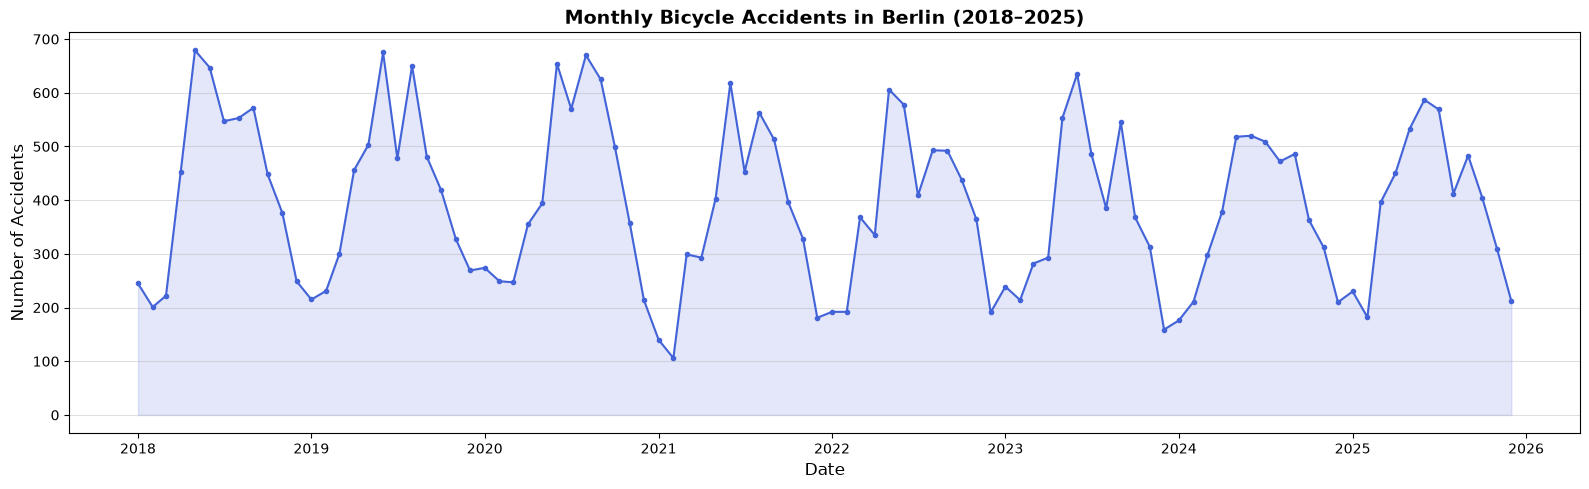

        date  accident_count
0 2018-01-01             245
1 2018-02-01             201
2 2018-03-01             222
3 2018-04-01             453
4 2018-05-01             679


In [7]:
import matplotlib.pyplot as plt
import pandas as pd

# Convert Year + Month to datetime format (defaulting to the 1st of each month)
df_berlin_rad_final['date'] = pd.to_datetime(
    df_berlin_rad_final[['year', 'month']].assign(day=1)
)

# Aggregate monthly accident counts (Monthly Time Series)
monthly_ts = (
    df_berlin_rad_final.groupby('date')
    .size()
    .reset_index(name='accident_count')
)

# Plotting the Time Series
plt.figure(figsize=(16, 5))
plt.plot(monthly_ts['date'], monthly_ts['accident_count'], 
         color='#4363d8', linewidth=1.5, marker='o', markersize=3)
plt.fill_between(monthly_ts['date'], monthly_ts['accident_count'], 
                 alpha=0.15, color='#4363d8')

plt.title('Monthly Bicycle Accidents in Berlin (2018–2025)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Number of Accidents', fontsize=12)
plt.grid(axis='y', alpha=0.4)
plt.tight_layout()

# Save and show plot
plt.savefig('../images/berlin_accidents_timeseries.png', dpi=300, bbox_inches='tight')
plt.show()

# Display first few rows of the aggregated dataset
print(monthly_ts.head())

### 3.2 Accidents by Month & Year

Yearly comparison reveals consistent summer peaks (May–August) across all years, confirming that accident frequency is strongly driven by cycling season rather than year-over-year changes.


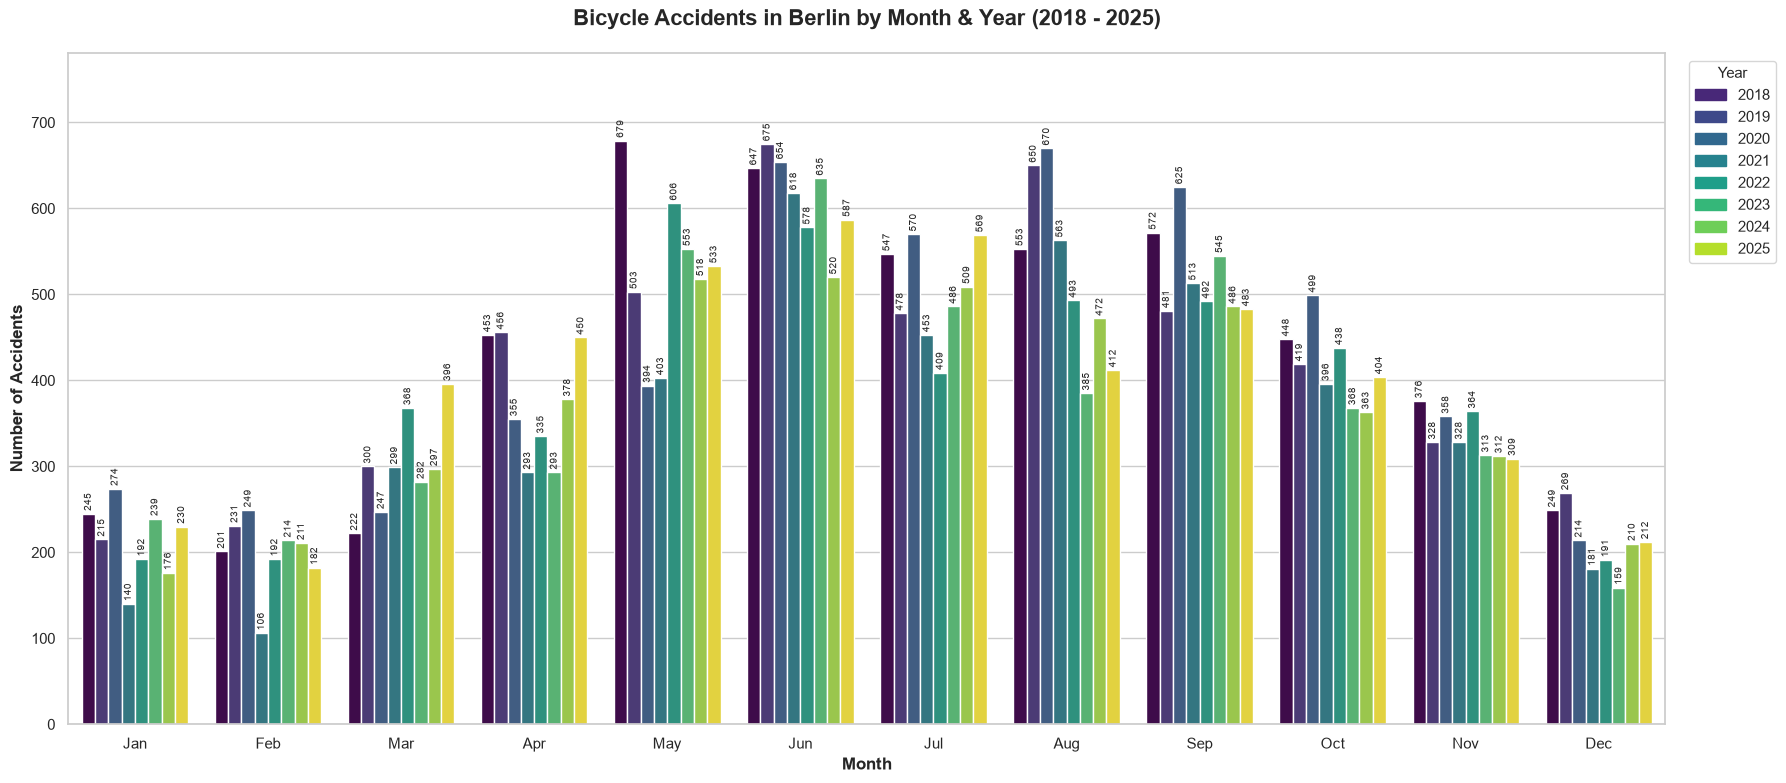

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.patches import Patch # Manuel lejant için gerekli

# 1. DATA CLEANING & YEAR CONVERSION
df_plot = df_berlin_rad_final.copy()

# Ensure year is strictly integer (converts string, float .0, etc.)
df_plot["year"] = pd.to_numeric(df_plot["year"], errors='coerce').fillna(0).astype(int)

# Map month numbers to month names
month_order = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
month_names = {i + 1: name for i, name in enumerate(month_order)}
df_plot["month_name"] = df_plot["month"].map(month_names)

# 2. GROUP DATA BY YEAR AND MONTH
monthly_yearly = (
    df_plot.groupby(["year", "month_name"])
    .size()
    .reset_index(name="accident_count")
)

# 3. EXPLICIT YEAR RANGE (2018 through 2025 - All 8 Years)
all_years = [2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]

# Reindex grid to guarantee all 8 years and 12 months are present
full_index = pd.MultiIndex.from_product(
    [all_years, month_order], names=["year", "month_name"]
)
monthly_yearly = (
    monthly_yearly.set_index(["year", "month_name"])
    .reindex(full_index, fill_value=0)
    .reset_index()
)

# 4. PLOT CONFIGURATION (Removed Seaborn Legend here)
plt.figure(figsize=(18, 8))
sns.set_theme(style="whitegrid")

ax = sns.barplot(
    data=monthly_yearly,
    x="month_name",
    y="accident_count",
    hue="year",
    order=month_order,
    hue_order=all_years,
    palette="viridis",
    legend=False # Tell Seaborn to not draw its automatic legend
)

# 5. DATA LABELS ON BARS (Hides 0s)
for container in ax.containers:
    labels = [
        f"{int(v)}" if (v > 0 and not np.isnan(v)) else ""
        for v in container.datavalues
    ]
    ax.bar_label(container, labels=labels, padding=2, fontsize=7, rotation=90)

# 6. TITLES AND LABELS
plt.title(
    "Bicycle Accidents in Berlin by Month & Year (2018 - 2025)",
    fontsize=16,
    fontweight="bold",
    pad=20,
)
plt.xlabel("Month", fontsize=12, fontweight="bold")
plt.ylabel("Number of Accidents", fontsize=12, fontweight="bold")

# 7. MANUALLY CREATE AND ADD THE LEGEND (Fix for Missing Years)
# First, generate the color map dynamically based on the number of years
viridis_colors = sns.color_palette("viridis", len(all_years))

# Create a list of 'Patch' objects (small color squares) with their labels
legend_patches = [
    Patch(color=viridis_colors[i], label=str(year))
    for i, year in enumerate(all_years)
]

# Add this manual legend to the plot in the same position
ax.legend(
    handles=legend_patches,
    title="Year",
    title_fontsize="11",
    bbox_to_anchor=(1.01, 1),
    loc="upper left"
)

plt.ylim(0, monthly_yearly["accident_count"].max() * 1.15)
plt.tight_layout()

# Save & Display
plt.savefig("../images/berlin_accidents_by_month_year_fixed_legend.png", dpi=300)
plt.show()

### 3.3 Temporal Dynamics: Day of Week & Hourly Peak Analysis
The day-by-hour accident heatmap indicates distinct rush-hour clusters on weekdays (07:00–09:00 and 15:00–18:00), corresponding to daily commuter routes. Conversely, weekend distribution shifts toward mid-day hours, highlighting a clear transition from functional commuting hazards to leisure riding patterns.

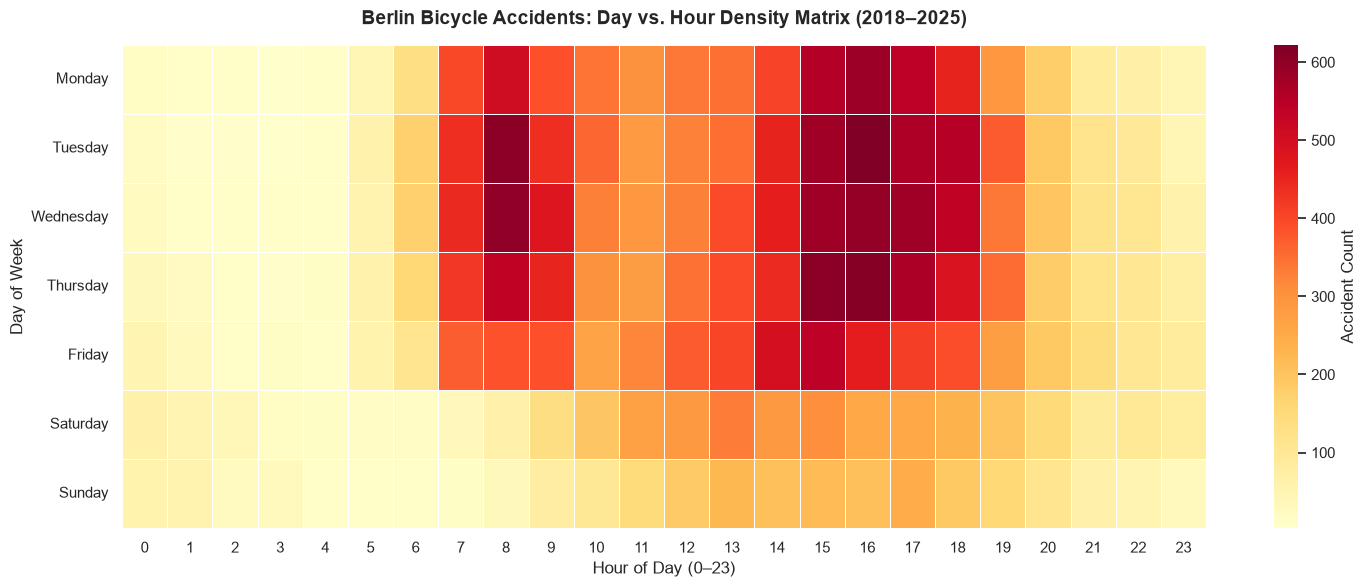

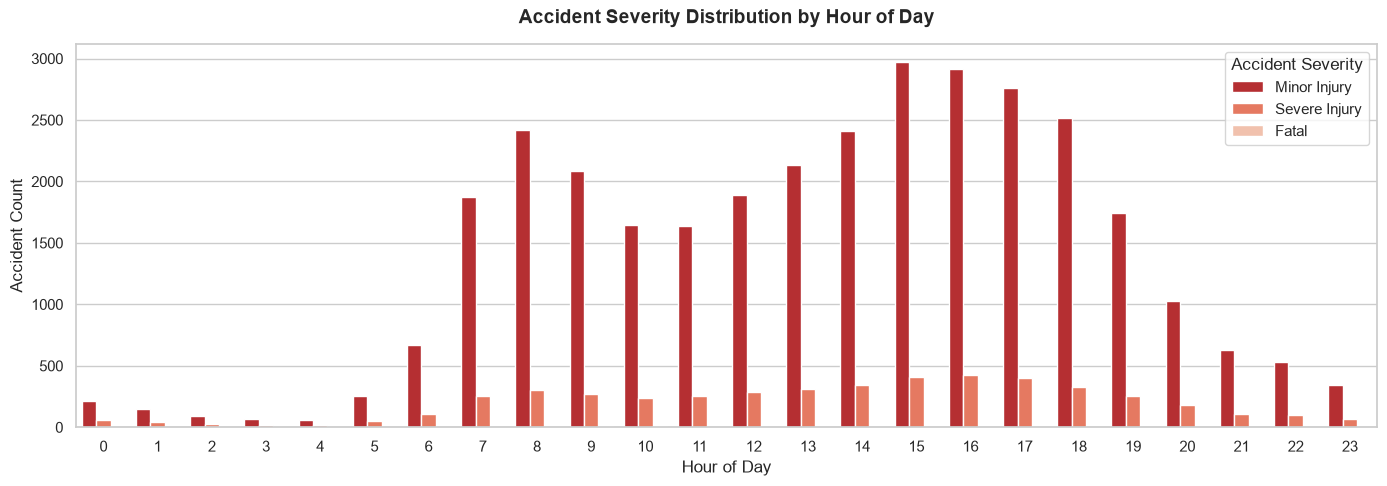

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set global plot style
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11})

# ---------------------------------------------------------
# 1. ACCIDENT DENSITY HEATMAP (DAY OF WEEK x HOUR OF DAY)
# ---------------------------------------------------------
# Define logical ordering for days of the week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Create pivot table (Rows: Days, Columns: Hours)
heatmap_data = df_berlin_rad_final.pivot_table(
    index='day_label', 
    columns='hour', 
    values='year', 
    aggfunc='count'
).reindex(day_order)

plt.figure(figsize=(15, 6))
sns.heatmap(
    heatmap_data, 
    cmap="YlOrRd", 
    annot=False, 
    linewidths=.5, 
    cbar_kws={'label': 'Accident Count'}
)

plt.title('Berlin Bicycle Accidents: Day vs. Hour Density Matrix (2018–2025)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Hour of Day (0–23)', fontsize=12)
plt.ylabel('Day of Week', fontsize=12)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 2. ACCIDENT COUNT AND SEVERITY DISTRIBUTION BY HOUR
# ---------------------------------------------------------
plt.figure(figsize=(14, 5))
sns.countplot(
    data=df_berlin_rad_final, 
    x='hour', 
    hue='severity_label', 
    palette='Reds_r'
)

plt.title('Accident Severity Distribution by Hour of Day', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Hour of Day', fontsize=12)
plt.ylabel('Accident Count', fontsize=12)
plt.legend(title='Accident Severity', labels=['Minor Injury', 'Severe Injury', 'Fatal'])
plt.tight_layout()
plt.show()

---
## 4. Collision Partner Analysis <a id='4-collision'></a>

Each accident record flags which vehicle types were involved alongside the bicycle. We classify accidents by their collision partner to understand the primary risk sources.


                             collision_type  count  percentage
0                             Bicycle + Car  25442        67.0
1                              Bicycle Only   5192        13.7
2                           Bicycle + Other   3125         8.2
3                      Bicycle + Pedestrian   2321         6.1
4                           Bicycle + Truck    721         1.9
5                      Bicycle + Motorcycle    652         1.7
6                     Bicycle + Car + Other    294         0.8
7                Bicycle + Car + Pedestrian     93         0.2
8                Bicycle + Car + Motorcycle     43         0.1
9                     Bicycle + Car + Truck     31         0.1
10                  Bicycle + Truck + Other     12         0.0
11             Bicycle + Pedestrian + Other      9         0.0
12        Bicycle + Pedestrian + Motorcycle      4         0.0
13  Bicycle + Car + Pedestrian + Motorcycle      3         0.0
14       Bicycle + Car + Motorcycle + Truck      1     

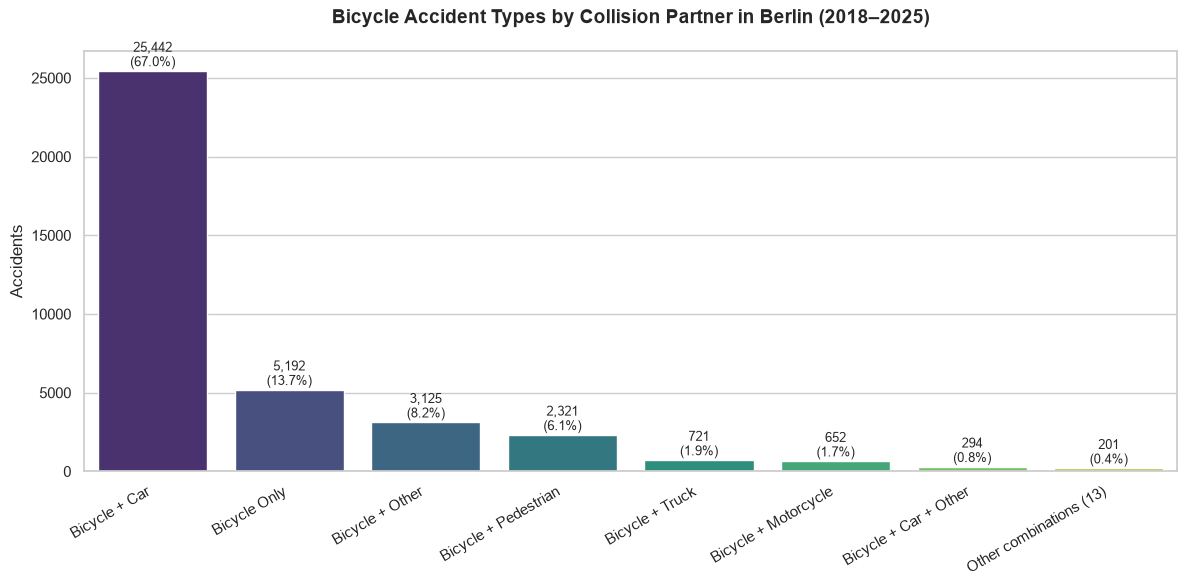

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

#  1. Create a combination column
def get_combination(row):
    """Classify a crash by which other party types were involved.

    `is_other_party` (IstSonstige) covers participants outside the named
    categories — most importantly other cyclists. Without it, bicycle-to-bicycle
    collisions are silently pooled with genuine single-bicycle falls, which are
    a different mechanism with different countermeasures.
    """
    others = []
    if row['is_car'] == 1:
        others.append('Car')
    if row['is_pedestrian'] == 1:
        others.append('Pedestrian')
    if row['is_motorcycle'] == 1:
        others.append('Motorcycle')
    if row['is_truck'] == 1:
        others.append('Truck')
    if row['is_other_party'] == 1:
        others.append('Other')
    if not others:
        return 'Bicycle Only'
    return 'Bicycle + ' + ' + '.join(others)

df_berlin_rad_final['collision_type'] = df_berlin_rad_final.apply(get_combination, axis=1)

# 2. Distribution
combo_counts = (
    df_berlin_rad_final['collision_type']
    .value_counts()
    .reset_index()
)
combo_counts.columns = ['collision_type', 'count']
combo_counts['percentage'] = (combo_counts['count'] / len(df_berlin_rad_final) * 100).round(1)

print(combo_counts.to_string())

# 3. Chart
# Collapse the long tail: 20 combinations is unreadable, and everything below
# 0.5% is a handful of rare multi-vehicle crashes.
THRESHOLD = 0.5
main = combo_counts[combo_counts['percentage'] >= THRESHOLD].copy()
tail = combo_counts[combo_counts['percentage'] < THRESHOLD]

if len(tail):
    main.loc[len(main)] = {
        'collision_type': f'Other combinations ({len(tail)})',
        'count': tail['count'].sum(),
        'percentage': round(tail['percentage'].sum(), 1),
    }

plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=main,
    x='collision_type',
    y='count',
    hue='collision_type',
    legend=False,
    palette='viridis',
)

for i, row in main.iterrows():
    ax.text(i, row['count'] + 300,
            f"{row['count']:,}\n({row['percentage']}%)",
            ha='center', fontsize=9)

ax.set_xlabel('')
ax.set_ylabel('Accidents')
ax.set_title('Bicycle Accident Types by Collision Partner in Berlin (2018–2025)',
             fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

In [11]:
print(df_berlin_rad_final['collision_type'].value_counts().to_string())
print()
solo = df_berlin_rad_final[df_berlin_rad_final['collision_type'] == 'Bicycle Only']
other = df_berlin_rad_final[df_berlin_rad_final['collision_type'] == 'Bicycle + Other']
for lbl, fr in [('Bicycle Only', solo), ('Bicycle + Other', other)]:
    n, ksi = len(fr), int(fr['is_ksi'].sum())
    lo, hi = wilson_ci(ksi, n)
    print(f"{lbl:18s} n={n:6,}  KSI {ksi/n:6.2%} [{lo:.2%}-{hi:.2%}]")

collision_type
Bicycle + Car                              25442
Bicycle Only                                5192
Bicycle + Other                             3125
Bicycle + Pedestrian                        2321
Bicycle + Truck                              721
Bicycle + Motorcycle                         652
Bicycle + Car + Other                        294
Bicycle + Car + Pedestrian                    93
Bicycle + Car + Motorcycle                    43
Bicycle + Car + Truck                         31
Bicycle + Truck + Other                       12
Bicycle + Pedestrian + Other                   9
Bicycle + Pedestrian + Motorcycle              4
Bicycle + Car + Pedestrian + Motorcycle        3
Bicycle + Car + Motorcycle + Truck             1
Bicycle + Car + Motorcycle + Other             1
Bicycle + Motorcycle + Other                   1
Bicycle + Motorcycle + Truck                   1
Bicycle + Car + Pedestrian + Other             1
Bicycle + Pedestrian + Truck                   1

Bicy

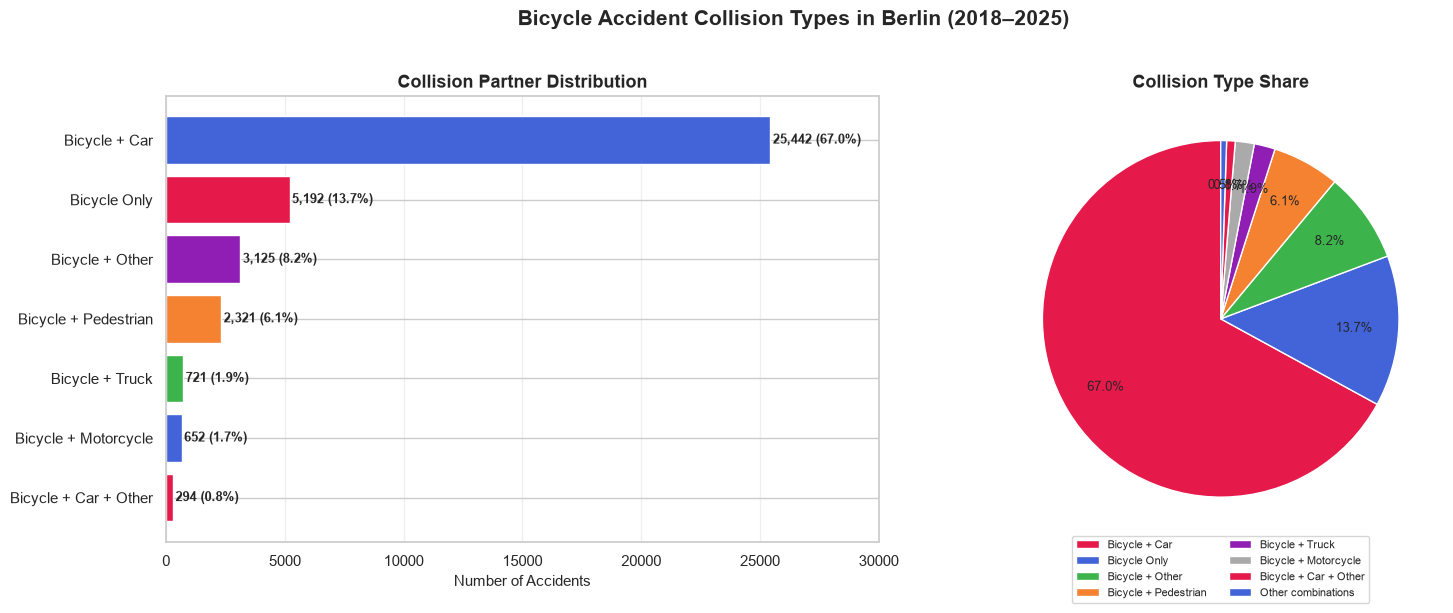

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Keep main combinations only (>0.5%)
combo_main = combo_counts[combo_counts['percentage'] >= 0.5].copy()
combo_rest = combo_counts[combo_counts['percentage'] < 0.5]['count'].sum()

# colors
colors = ['#e6194b','#4363d8','#3cb44b','#f58231','#911eb4']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Bar chart
ax1 = axes[0]
bars = ax1.barh(combo_main['collision_type'][::-1], 
                combo_main['count'][::-1], 
                color=colors[:len(combo_main)])
for bar, (_, row) in zip(bars, combo_main[::-1].iterrows()):
    ax1.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
             f"{row['count']:,} ({row['percentage']}%)",
             va='center', fontsize=9, fontweight='bold')
ax1.set_xlabel('Number of Accidents', fontsize=11)
ax1.set_title('Collision Partner Distribution', fontsize=13, fontweight='bold')
ax1.set_xlim(0, 30000)
ax1.grid(axis='x', alpha=0.3)

# Right: Pie chart
ax2 = axes[1]
pie_data = list(combo_main['count']) + [combo_rest]
pie_labels = list(combo_main['collision_type']) + ['Other combinations']
pie_colors = colors + ['#aaaaaa']
wedges, texts, autotexts = ax2.pie(
    pie_data,
    labels=None,
    autopct='%1.1f%%',
    colors=pie_colors,
    startangle=90,
    pctdistance=0.75
)
for autotext in autotexts:
    autotext.set_fontsize(9)
ax2.legend(pie_labels, loc='lower center', bbox_to_anchor=(0.5, -0.15),
           fontsize=8, ncol=2)
ax2.set_title('Collision Type Share', fontsize=13, fontweight='bold')

plt.suptitle('Bicycle Accident Collision Types in Berlin (2018–2025)',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../images/berlin_collision_types.png', dpi=300, bbox_inches='tight')
plt.show()

### 4.1 Solo Crashes — Road & Light Conditions

**Hypothesis:** Bicycle-only crashes (no other vehicle) occur more often on wet or icy roads.

We test this by comparing road and light conditions between solo crashes and all
**other** crashes. Comparing against the full dataset would be biased, because
solo crashes are themselves part of that dataset.


In [13]:
## Filter: Bicycle Only accidents (no other vehicle involved)
df_bike_only = df_berlin_rad_final[df_berlin_rad_final['collision_type'] == 'Bicycle Only']

print(f"Bicycle Only accidents: {len(df_bike_only)}")

print(f"\nRoad conditions distribution:")
print(df_bike_only['road_label'].value_counts())

print(f"\nAs percentage:")
print((df_bike_only['road_label'].value_counts() / len(df_bike_only) * 100).round(1))

print("\n--- Comparison: All accidents ---")
print((df_berlin_rad_final['road_label'].value_counts() / len(df_berlin_rad_final) * 100).round(1))

Bicycle Only accidents: 5192

Road conditions distribution:
road_label
dry         4248
wet_damp     862
ice_snow      82
Name: count, dtype: int64

As percentage:
road_label
dry         81.8
wet_damp    16.6
ice_snow     1.6
Name: count, dtype: float64

--- Comparison: All accidents ---
road_label
dry         82.1
wet_damp    17.4
ice_snow     0.6
Name: count, dtype: float64


collision_type
Bicycle + Car                              25442
Bicycle Only                                5192
Bicycle + Other                             3125
Bicycle + Pedestrian                        2321
Bicycle + Truck                              721
Bicycle + Motorcycle                         652
Bicycle + Car + Other                        294
Bicycle + Car + Pedestrian                    93
Bicycle + Car + Motorcycle                    43
Bicycle + Car + Truck                         31
Bicycle + Truck + Other                       12
Bicycle + Pedestrian + Other                   9
Bicycle + Pedestrian + Motorcycle              4
Bicycle + Car + Pedestrian + Motorcycle        3
Bicycle + Car + Motorcycle + Truck             1
Bicycle + Car + Motorcycle + Other             1
Bicycle + Motorcycle + Other                   1
Bicycle + Motorcycle + Truck                   1
Bicycle + Car + Pedestrian + Other             1
Bicycle + Pedestrian + Truck                   1
Name:

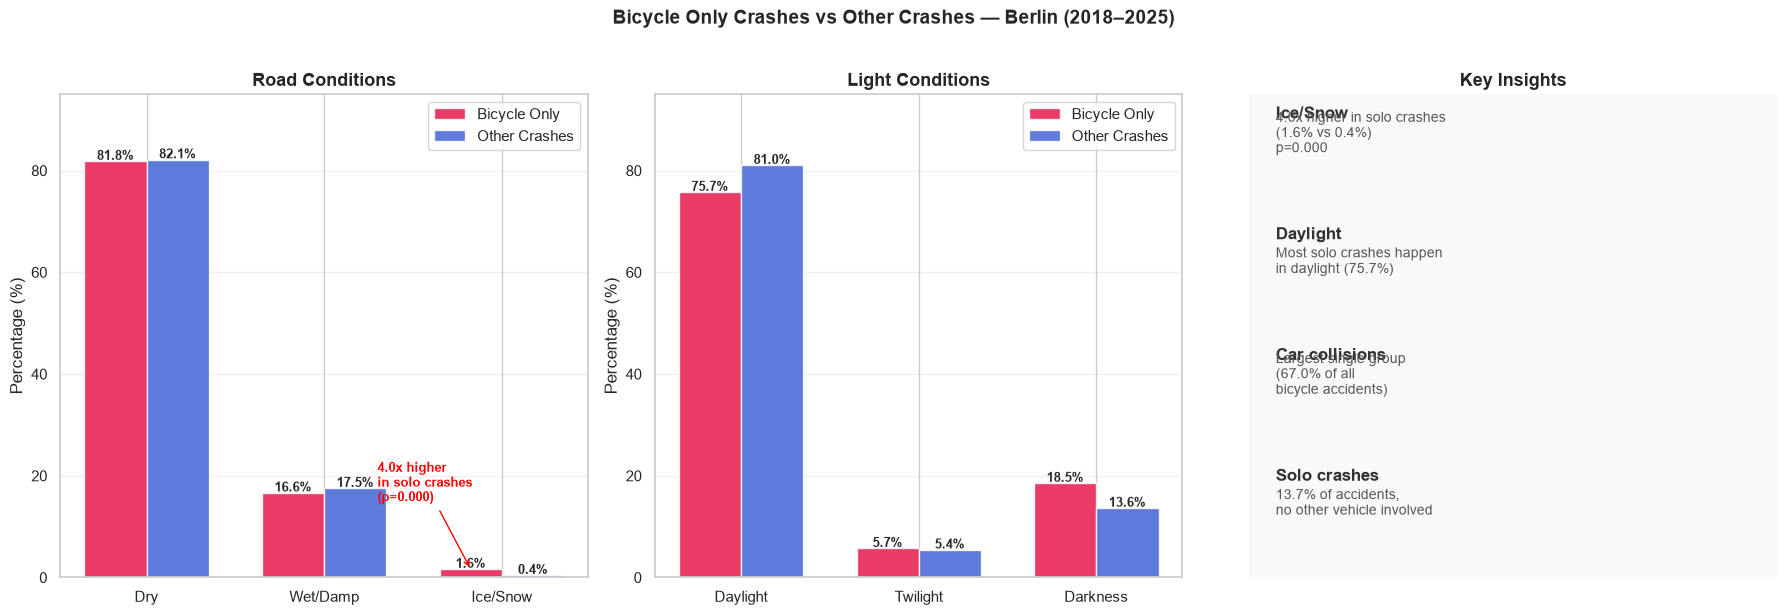

In [14]:
import matplotlib.pyplot as plt
import numpy as np


# ── Sanity check: confirm the collision_type categories exist as expected ──
print(df_berlin_rad_final['collision_type'].value_counts(), '\n')

SOLO_LABEL = 'Bicycle Only'
solo     = df_berlin_rad_final[df_berlin_rad_final['collision_type'] == SOLO_LABEL]
non_solo = df_berlin_rad_final[df_berlin_rad_final['collision_type'] != SOLO_LABEL]

assert len(solo) > 0, f"No rows matched collision_type == '{SOLO_LABEL}'"


# ── Category orders (fixed, never rely on value_counts ordering) ──
road_order  = ['dry', 'wet_damp', 'ice_snow']
light_order = ['daylight', 'twilight', 'darkness']

categories = ['Dry', 'Wet/Damp', 'Ice/Snow']
light_cats = ['Daylight', 'Twilight', 'Darkness']

# Solo crashes are compared against NON-solo crashes.
# Comparing them against the full dataset would be biased, because
# solo crashes are themselves a subset of that dataset.
solo_road  = category_share(solo,     'road_label',  road_order)
other_road = category_share(non_solo, 'road_label',  road_order)
solo_light  = category_share(solo,     'light_label', light_order)
other_light = category_share(non_solo, 'light_label', light_order)

# ── Statistical check for the ice/snow claim ──
ice_counts = [(solo['road_label'] == 'ice_snow').sum(),
              (non_solo['road_label'] == 'ice_snow').sum()]
ice_totals = [len(solo), len(non_solo)]
ice_z, ice_p = two_proportion_ztest(ice_counts, ice_totals)
ice_ratio = (ice_counts[0] / ice_totals[0]) / (ice_counts[1] / ice_totals[1])

print(f"Ice/snow share — solo: {solo_road[2]}% (n={ice_counts[0]}) | "
      f"other: {other_road[2]}% (n={ice_counts[1]})")
print(f"Ratio: {ice_ratio:.2f}x | z={ice_z:.2f}, p={ice_p:.4f}")

SIGNIFICANCE = 0.05
ice_is_significant = ice_p < SIGNIFICANCE

# ── Figures used in the insight card, all derived from the data ──
solo_share    = len(solo) / len(df_berlin_rad_final) * 100
daylight_solo = solo_road_daylight = solo_light[0]
car_share     = (
    (df_berlin_rad_final['collision_type'] == 'Bicycle + Car').mean() * 100
)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
x = np.arange(len(categories))
width = 0.35


def grouped_bars(ax, labels, series_a, series_b, title, ticks):
    """Draw a two-series grouped bar chart with value labels."""
    pos = np.arange(len(ticks))
    bars_a = ax.bar(pos - width / 2, series_a, width,
                    label='Bicycle Only', color='#e6194b', alpha=0.85)
    bars_b = ax.bar(pos + width / 2, series_b, width,
                    label='Other Crashes', color='#4363d8', alpha=0.85)
    for bar in list(bars_a) + list(bars_b):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                f'{bar.get_height():.1f}%', ha='center',
                fontsize=9, fontweight='bold')
    ax.set_xticks(pos)
    ax.set_xticklabels(ticks)
    ax.set_ylabel('Percentage (%)')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.legend()
    ax.set_ylim(0, 95)
    ax.grid(axis='y', alpha=0.3)
    return bars_a, bars_b


# 1. Road conditions
grouped_bars(axes[0], categories, solo_road, other_road,
             'Road Conditions', categories)

# Annotate the ice/snow difference only if it survives a significance test.
if ice_is_significant:
    axes[0].annotate(
        f'{ice_ratio:.1f}x higher\nin solo crashes\n(p={ice_p:.3f})',
        xy=(2 - width / 2, solo_road[2]), xytext=(1.3, 15),
        arrowprops=dict(arrowstyle='->', color='red'),
        color='red', fontsize=9, fontweight='bold',
    )

# 2. Light conditions
grouped_bars(axes[1], light_cats, solo_light, other_light,
             'Light Conditions', light_cats)

# 3. Summary insight card
ax3 = axes[2]
ax3.axis('off')
ax3.add_patch(plt.Rectangle((0, 0), 1, 1, fill=True,
              color='#f8f9fa', transform=ax3.transAxes, zorder=0))

ice_verdict = (
    f"{ice_ratio:.1f}x higher in solo crashes\n"
    f"({solo_road[2]}% vs {other_road[2]}%)\n"
    f"p={ice_p:.3f}"
    if ice_is_significant
    else f"No significant difference\n({solo_road[2]}% vs {other_road[2]}%)\n"
         f"p={ice_p:.3f}"
)

insights = [
    ("Ice/Snow", ice_verdict),
    ("Daylight", f"Most solo crashes happen\nin daylight ({solo_light[0]}%)"),
    ("Car collisions", f"Largest single group\n({car_share:.1f}% of all\nbicycle accidents)"),
    ("Solo crashes", f"{solo_share:.1f}% of accidents,\nno other vehicle involved"),
]

y_pos = 0.95
for heading, detail in insights:
    ax3.text(0.05, y_pos, heading, transform=ax3.transAxes,
             fontsize=12, fontweight='bold', color='#333333')
    ax3.text(0.05, y_pos - 0.07, detail, transform=ax3.transAxes,
             fontsize=10, color='#555555')
    y_pos -= 0.25

ax3.set_title('Key Insights', fontsize=13, fontweight='bold')

plt.suptitle(f'Bicycle Only Crashes vs Other Crashes — Berlin (2018–2025)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../images/berlin_solo_crash_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

### 4.2 Truck Involvement and Injury Severity

**Hypothesis:** Crashes involving a heavy goods vehicle produce a
disproportionate share of severe outcomes, even though they are a small
fraction of all bicycle crashes.

**Why this can be tested with this dataset.** The comparison is conditional on
a crash having occurred: both numerator and denominator are crashes, so no
cycling exposure data is required. This makes it one of the few risk questions
answerable from the Unfallatlas alone.

**Outcome measure:** KSI (killed or seriously injured), the standard road-safety
outcome and the metric Berlin's Vision Zero targets are expressed in.
Fatalities alone are too rare here (74 cases over 8 years) to support
subgroup comparison.

**Baseline:** 12.99% of all Berlin bicycle crashes result in KSI.

In [15]:

import pandas as pd

bike = df_berlin_rad_final

assert bike['is_truck'].notna().all(), "is_truck has missing values"
assert set(bike['is_truck'].unique()) <= {0, 1}, "is_truck is not binary"


# ── Baseline ──
BASE_KSI = bike['is_ksi'].mean()
print(f"Baseline KSI share (all bicycle crashes): {BASE_KSI:.2%}\n")

# ── KSI rate by truck involvement ──
truck    = bike[bike['is_truck'] == 1]
no_truck = bike[bike['is_truck'] == 0]

rows = []
for label, frame in [('Truck involved', truck), ('No truck', no_truck)]:
    n = len(frame)
    ksi = int(frame['is_ksi'].sum())
    fatal = int((frame['accident_severity'] == 1).sum())
    lo, hi = wilson_ci(ksi, n)
    rows.append({
        'group': label,
        'crashes': n,
        'share_of_all': n / len(bike),
        'ksi': ksi,
        'ksi_rate': ksi / n,
        'ksi_ci_low': lo,
        'ksi_ci_high': hi,
        'fatal': fatal,
        'fatal_rate': fatal / n,
    })

summary = pd.DataFrame(rows)
print(summary.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

# ── Effect size ──
rr_ksi = summary.loc[0, 'ksi_rate'] / summary.loc[1, 'ksi_rate']
rr_fatal = (summary.loc[0, 'fatal_rate'] / summary.loc[1, 'fatal_rate']
            if summary.loc[1, 'fatal_rate'] > 0 else float('nan'))

z, p = two_proportion_ztest(
    [summary.loc[0, 'ksi'], summary.loc[1, 'ksi']],
    [summary.loc[0, 'crashes'], summary.loc[1, 'crashes']],
)

print(f"\nKSI risk ratio (truck vs no truck):   {rr_ksi:.2f}x")
print(f"Fatality risk ratio:                  {rr_fatal:.2f}x")
print(f"Two-proportion z-test: z={z:.2f}, p={p:.2e}")

# ── Share of all fatalities attributable to truck crashes ──
fatal_total = int((bike['accident_severity'] == 1).sum())
fatal_truck = int(((bike['is_truck'] == 1) & (bike['accident_severity'] == 1)).sum())
print(f"\nTruck crashes are {len(truck) / len(bike):.1%} of all bicycle crashes")
print(f"but account for {fatal_truck / fatal_total:.1%} "
      f"of all cyclist fatalities ({fatal_truck} of {fatal_total})")

# ── Mechanism: which conflict types dominate truck crashes? ──
print("\nConflict type distribution (%), truck vs no truck:")
mech = pd.DataFrame({
    'truck': truck['accident_type_label'].value_counts(normalize=True) * 100,
    'no_truck': no_truck['accident_type_label'].value_counts(normalize=True) * 100,
}).fillna(0)
mech['difference'] = mech['truck'] - mech['no_truck']
print(mech.sort_values('difference', ascending=False).round(1).to_string())

Baseline KSI share (all bicycle crashes): 12.99%

         group  crashes  share_of_all  ksi  ksi_rate  ksi_ci_low  ksi_ci_high  fatal  fatal_rate
Truck involved      767        0.0202  209    0.2725      0.2422       0.3051     32      0.0417
      No truck    37181        0.9798 4721    0.1270      0.1236       0.1304     42      0.0011

KSI risk ratio (truck vs no truck):   2.15x
Fatality risk ratio:                  36.93x
Two-proportion z-test: z=11.86, p=1.80e-32

Truck crashes are 2.0% of all bicycle crashes
but account for 43.2% of all cyclist fatalities (32 of 74)

Conflict type distribution (%), truck vs no truck:
                            truck  no_truck  difference
accident_type_label                                    
turning_accident             52.2      30.8        21.4
longitudinal_traffic         20.3      11.6         8.8
stationary_traffic           12.1      12.7        -0.6
crossing_pedestrian           0.0       4.3        -4.3
other_accident                3.

In [16]:
car_only = bike[(bike['is_car'] == 1) & (bike['is_truck'] == 0)]

print(f"Truck crashes:    {len(truck):,}")
print(f"Car-only crashes: {len(car_only):,}\n")

# KSI comparison against a like-for-like group
for label, frame in [('Truck', truck), ('Car only', car_only)]:
    n, ksi = len(frame), int(frame['is_ksi'].sum())
    lo, hi = wilson_ci(ksi, n)
    f = int((frame['accident_severity'] == 1).sum())
    f_lo, f_hi = wilson_ci(f, n)
    print(f"{label:10s} n={n:6,}  KSI {ksi/n:6.2%} [{lo:.2%}–{hi:.2%}]  "
          f"fatal {f/n:6.3%} [{f_lo:.3%}–{f_hi:.3%}]")

z, p = two_proportion_ztest(
    [int(truck['is_ksi'].sum()), int(car_only['is_ksi'].sum())],
    [len(truck), len(car_only)],
)
print(f"\nz={z:.2f}, p={p:.2e}")

print("\nConflict type (%), truck vs car-only:")
mech2 = pd.DataFrame({
    'truck': truck['accident_type_label'].value_counts(normalize=True) * 100,
    'car_only': car_only['accident_type_label'].value_counts(normalize=True) * 100,
}).fillna(0)
mech2['difference'] = mech2['truck'] - mech2['car_only']
print(mech2.sort_values('difference', ascending=False).round(1).to_string())

Truck crashes:    767
Car-only crashes: 25,877

Truck      n=   767  KSI 27.25% [24.22%–30.51%]  fatal 4.172% [2.971%–5.830%]
Car only   n=25,877  KSI 10.59% [10.22%–10.97%]  fatal 0.089% [0.059%–0.133%]

z=14.49, p=1.44e-47

Conflict type (%), truck vs car-only:
                            truck  car_only  difference
accident_type_label                                    
turning_accident             52.2      37.9        14.3
longitudinal_traffic         20.3       9.4        10.9
driving_accident              0.8       1.0        -0.2
crossing_pedestrian           0.0       0.2        -0.2
other_accident                3.0       4.4        -1.4
stationary_traffic           12.1      16.7        -4.5
entering_crossing_accident   11.6      30.5       -18.8


In [17]:
# Excess burden: how many severe outcomes above the car-only baseline?
ksi_rate_truck = truck['is_ksi'].mean()
ksi_rate_car   = car_only['is_ksi'].mean()
fat_rate_truck = (truck['accident_severity'] == 1).mean()
fat_rate_car   = (car_only['accident_severity'] == 1).mean()

n_truck = len(truck)
excess_ksi   = n_truck * (ksi_rate_truck - ksi_rate_car)
excess_fatal = n_truck * (fat_rate_truck - fat_rate_car)

print("Excess severe outcomes in truck crashes, relative to the")
print("car-only severity baseline (2018–2025):\n")
print(f"  Excess KSI:        {excess_ksi:6.0f}  "
      f"(of {int(truck['is_ksi'].sum())} observed)")
print(f"  Excess fatalities: {excess_fatal:6.1f}  "
      f"(of {int((truck['accident_severity']==1).sum())} observed)")

# Which mechanism carries the truck fatalities?
print("\nTruck-involved crashes: severity by conflict type")
tab = pd.crosstab(truck['accident_type_label'], truck['severity_label'])
tab['n'] = tab.sum(axis=1)
tab['ksi_rate'] = (tab.get('fatal', 0) + tab.get('serious_injury', 0)) / tab['n']
print(tab.sort_values('ksi_rate', ascending=False).round(3).to_string())

Excess severe outcomes in truck crashes, relative to the
car-only severity baseline (2018–2025):

  Excess KSI:           128  (of 209 observed)
  Excess fatalities:   31.3  (of 32 observed)

Truck-involved crashes: severity by conflict type
severity_label              fatal  minor_injury  serious_injury    n  ksi_rate
accident_type_label                                                           
driving_accident                0             4               2    6     0.333
turning_accident               23           274             103  400     0.315
entering_crossing_accident      2            62              25   89     0.303
longitudinal_traffic            3           119              34  156     0.237
other_accident                  1            19               3   23     0.174
stationary_traffic              3            80              10   93     0.140


## Key Finding

Trucks account for **2.0%** of Berlin's reported bicycle crashes (767 of 37,948,
2018–2025) but **43.2%** of cyclist fatalities (32 of 74).

Compared like-for-like against bicycle–car crashes, truck involvement carries:

- **2.57x** the rate of killed-or-seriously-injured outcomes
  (27.3% [24.2–30.5] vs 10.6% [10.2–11.0])
- at least a **20-fold** higher fatality rate
  (4.17% [2.97–5.83] vs 0.089% [0.059–0.133])

The risk is mechanism-specific rather than general. Truck crashes are
concentrated in turning conflicts (52.2% vs 37.9%) and overtaking/longitudinal
conflicts (20.3% vs 9.4%), and are *under*-represented in junction-entry
conflicts (11.6% vs 30.5%). Together, turning and overtaking account for 72.5%
of truck crashes versus 47.3% of car crashes.

**Limitations.** The comparison is conditional on a crash occurring, so it
measures severity, not collision probability — no cycling exposure data is
required, but none is implied either. Trucks concentrate on arterial roads with
higher speed limits, so part of the effect reflects road environment rather than
vehicle type alone. Fatality counts are small (32 cases): the direction is
robust, the exact ratio is not.

In [18]:
by_hour = (bike.groupby('hour')['is_truck']
             .agg(truck_share='mean', truck_n='sum', total='size'))
by_hour['truck_share'] *= 100
print(by_hour.round(2).to_string())

print("\nTruck crash share by weekday:")
print((bike.groupby('day_label')['is_truck'].mean() * 100).round(2).to_string())

      truck_share  truck_n  total
hour                             
0            0.74      2.0    269
1            0.53      1.0    188
2            0.00      0.0    112
3            0.00      0.0     87
4            5.00      4.0     80
5            2.32      7.0    302
6            2.96     23.0    778
7            3.20     68.0   2124
8            3.44     94.0   2734
9            4.23    100.0   2363
10           3.80     72.0   1893
11           3.32     63.0   1895
12           3.80     83.0   2187
13           2.08     51.0   2448
14           1.67     46.0   2754
15           1.68     57.0   3387
16           1.26     42.0   3341
17           0.60     19.0   3164
18           0.60     17.0   2851
19           0.50     10.0   1995
20           0.49      6.0   1214
21           0.14      1.0    737
22           0.16      1.0    628
23           0.00      0.0    417

Truck crash share by weekday:
day_label
Friday       2.49
Monday       2.85
Saturday     0.37
Sunday       0.08
Thu

In [19]:
truck_turn = truck[truck['accident_type_label'] == 'turning_accident']
print(f"Truck turning crashes: {len(truck_turn)}\n")
print("By district (count and KSI rate):")
d = truck_turn.groupby('district_name').agg(
    n=('is_ksi', 'size'), ksi=('is_ksi', 'sum'), fatal=('accident_severity', lambda s: (s == 1).sum())
)
d['ksi_rate'] = (d['ksi'] / d['n']).round(3)
print(d.sort_values('n', ascending=False).to_string())

Truck turning crashes: 400

By district (count and KSI rate):
                             n  ksi  fatal  ksi_rate
district_name                                       
Mitte                       92   23      4     0.250
Friedrichshain-Kreuzberg    49    9      2     0.184
Treptow-Köpenick            40   17      3     0.425
Tempelhof-Schöneberg        35   14      3     0.400
Charlottenburg-Wilmersdorf  31   10      1     0.323
Pankow                      28   13      1     0.464
Reinickendorf               27   10      3     0.370
Steglitz-Zehlendorf         27    8      1     0.296
Lichtenberg                 23   10      1     0.435
Neukölln                    19    4      2     0.211
Spandau                     18    5      1     0.278
Marzahn-Hellersdorf         11    3      1     0.273


In [20]:
rows = []
for name, g in truck_turn.groupby('district_name'):
    n, ksi = len(g), int(g['is_ksi'].sum())
    lo, hi = wilson_ci(ksi, n)
    rows.append({'district': name, 'n': n, 'ksi': ksi,
                 'ksi_rate': ksi / n, 'ci_low': lo, 'ci_high': hi,
                 'ci_width': hi - lo})

dist = pd.DataFrame(rows).sort_values('ksi_rate', ascending=False)
print(dist.to_string(index=False, float_format=lambda v: f"{v:.3f}"))
print("\nNote how CI width scales inversely with n — Marzahn's estimate")
print("rests on 3 KSI cases and is essentially uninformative.")

                  district  n  ksi  ksi_rate  ci_low  ci_high  ci_width
                    Pankow 28   13     0.464   0.295    0.642     0.347
               Lichtenberg 23   10     0.435   0.256    0.632     0.376
          Treptow-Köpenick 40   17     0.425   0.285    0.578     0.293
      Tempelhof-Schöneberg 35   14     0.400   0.256    0.564     0.309
             Reinickendorf 27   10     0.370   0.215    0.558     0.342
Charlottenburg-Wilmersdorf 31   10     0.323   0.186    0.499     0.313
       Steglitz-Zehlendorf 27    8     0.296   0.159    0.485     0.326
                   Spandau 18    5     0.278   0.125    0.509     0.384
       Marzahn-Hellersdorf 11    3     0.273   0.097    0.566     0.468
                     Mitte 92   23     0.250   0.173    0.347     0.175
                  Neukölln 19    4     0.211   0.085    0.433     0.348
  Friedrichshain-Kreuzberg 49    9     0.184   0.100    0.314     0.214

Note how CI width scales inversely with n — Marzahn's estimate


In [21]:
from scipy.stats import chi2_contingency

tab = pd.crosstab(truck_turn['district_name'], truck_turn['is_ksi'])
chi2, p, dof, expected = chi2_contingency(tab)

print(tab.to_string())
print(f"\nChi-square test of homogeneity across 12 districts:")
print(f"  chi2 = {chi2:.2f}, df = {dof}, p = {p:.3f}")
print(f"  Cells with expected count < 5: {(expected < 5).sum()} of {expected.size}")

# Because several expected counts are small, verify with a Monte Carlo /
# permutation approach rather than trusting the asymptotic chi-square.
import numpy as np
rng = np.random.default_rng(42)
obs = chi2
labels = truck_turn['district_name'].to_numpy()
ksi = truck_turn['is_ksi'].to_numpy()
count = 0
for _ in range(10000):
    perm = rng.permutation(ksi)
    c, _, _, _ = chi2_contingency(pd.crosstab(labels, perm))
    count += (c >= obs)
print(f"  Permutation p-value ({10000} draws): {count / 10000:.4f}")

is_ksi                       0   1
district_name                     
Charlottenburg-Wilmersdorf  21  10
Friedrichshain-Kreuzberg    40   9
Lichtenberg                 13  10
Marzahn-Hellersdorf          8   3
Mitte                       69  23
Neukölln                    15   4
Pankow                      15  13
Reinickendorf               17  10
Spandau                     13   5
Steglitz-Zehlendorf         19   8
Tempelhof-Schöneberg        21  14
Treptow-Köpenick            23  17

Chi-square test of homogeneity across 12 districts:
  chi2 = 15.16, df = 11, p = 0.175
  Cells with expected count < 5: 1 of 24
  Permutation p-value (10000 draws): 0.1707


In [22]:
truck_turn = truck_turn.copy()
truck_turn['cell'] = (truck_turn['latitude'].round(4).astype(str) + '_' +
                      truck_turn['longitude'].round(4).astype(str))

hot = (truck_turn.groupby('cell')
       .agg(n=('is_ksi', 'size'), ksi=('is_ksi', 'sum'),
            fatal=('accident_severity', lambda s: (s == 1).sum()),
            lat=('latitude', 'mean'), lon=('longitude', 'mean'),
            district=('district_name', 'first'))
       .sort_values(['fatal', 'n'], ascending=False))

print(f"Distinct locations: {len(hot)} for {len(truck_turn)} crashes")
print(f"Locations with 2+ crashes: {(hot['n'] >= 2).sum()}")
print(hot[hot['n'] >= 2].head(15).to_string())

Distinct locations: 365 for 400 crashes
Locations with 2+ crashes: 29
                 n  ksi  fatal        lat        lon                    district
cell                                                                            
52.5253_13.4203  2    1      1  52.525282  13.420330                       Mitte
52.5782_13.298   2    2      1  52.578203  13.297970               Reinickendorf
52.4975_13.3893  4    2      0  52.497488  13.389265    Friedrichshain-Kreuzberg
52.5271_13.416   4    1      0  52.527099  13.415977                       Mitte
52.4661_13.4961  3    2      0  52.466052  13.496100            Treptow-Köpenick
52.5456_13.4447  3    2      0  52.545639  13.444671                      Pankow
52.4136_13.3619  2    0      0  52.413624  13.361938        Tempelhof-Schöneberg
52.4144_13.401   2    0      0  52.414428  13.400963        Tempelhof-Schöneberg
52.4648_13.5135  2    0      0  52.464775  13.513528            Treptow-Köpenick
52.4689_13.5146  2    0      0  52.4688

---
## 5. Temporal Analysis <a id='5-temporal'></a>

### 5.1 Bicycle vs Car Accidents by Hour

We focus on the most common collision type (Bicycle + Car, 67.8%) and examine at which hours of the day accidents peak. Values represent **yearly averages** to account for differences in data volume across years.


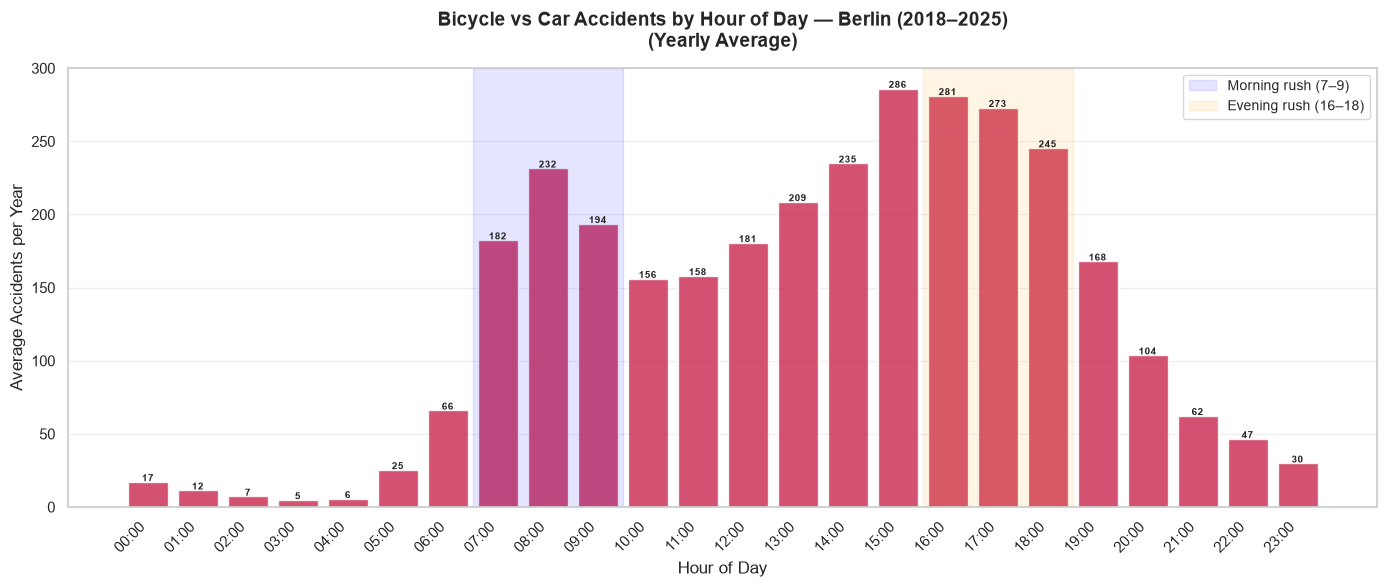

Top 5 most dangerous hours (yearly average):
 hour  count
   15  286.1
   16  281.1
   17  273.0
   18  245.4
   14  235.0


In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter: Bicycle + Car accidents only
df_bike_car = df_berlin_rad_final[df_berlin_rad_final['collision_type'] == 'Bicycle + Car']

# Yearly average per hour
hourly_avg = (df_bike_car.groupby(['year', 'hour'])
              .size()
              .reset_index(name='count')
              .groupby('hour')['count']
              .mean()
              .round(1)
              .reset_index())

plt.figure(figsize=(14, 6))
ax = sns.barplot(data=hourly_avg, x='hour', y='count', color='#e6194b', alpha=0.85)

# Add value labels on bars
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.0f}', ha='center', fontsize=7.5, fontweight='bold')

# Highlight rush hours
ax.axvspan(6.5, 9.5, alpha=0.1, color='blue', label='Morning rush (7–9)')
ax.axvspan(15.5, 18.5, alpha=0.1, color='orange', label='Evening rush (16–18)')

plt.title('Bicycle vs Car Accidents by Hour of Day — Berlin (2018–2025)\n(Yearly Average)',
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Hour of Day', fontsize=12)
plt.ylabel('Average Accidents per Year', fontsize=12)
plt.xticks(range(24), [f'{h:02d}:00' for h in range(24)], rotation=45, ha='right')
plt.legend(fontsize=10)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../images/berlin_bike_car_by_hour_avg.png', dpi=300, bbox_inches='tight')
plt.show()

print("Top 5 most dangerous hours (yearly average):")
print(hourly_avg.nlargest(5, 'count').to_string(index=False))

### 5.2 Accidents by Day of Week

**Hypothesis 1 — Monday effect:** Cyclists are less alert at the start of the week.  
**Hypothesis 2 — Friday effect:** Impatience before the weekend leads to more risk-taking.


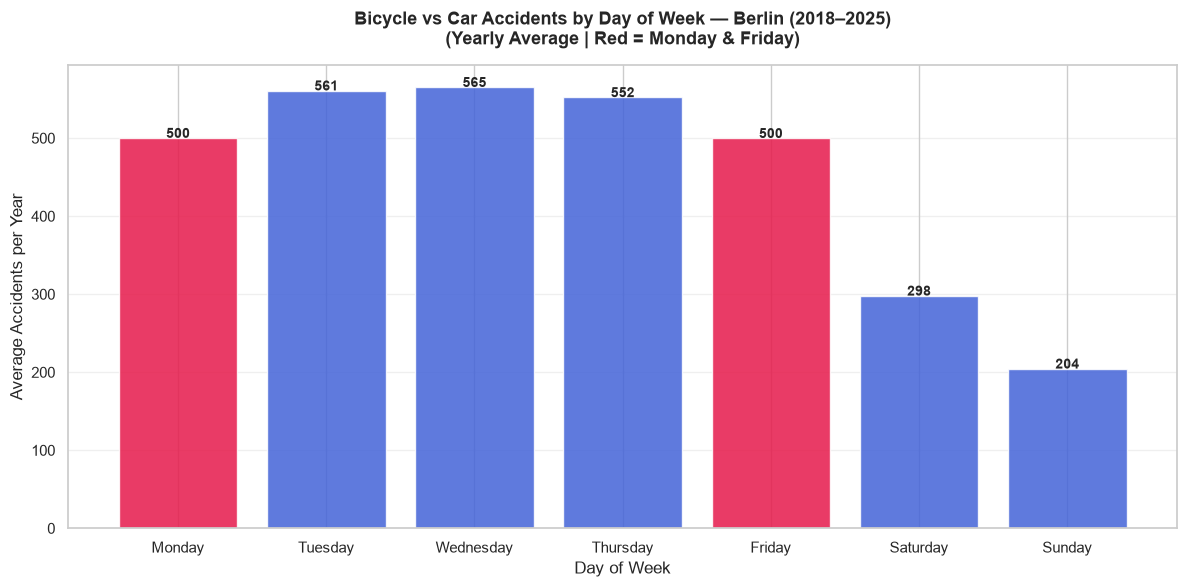

Average accidents by day of week:
 day_name  count
   Monday  500.0
  Tuesday  560.8
Wednesday  565.2
 Thursday  552.2
   Friday  499.8
 Saturday  297.9
   Sunday  204.4


In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Day order and names (Germany: 1=Sunday, 2=Monday, ..., 7=Saturday)
day_order = [2, 3, 4, 5, 6, 7, 1]  # Monday → Sunday
day_names = {1:'Sunday', 2:'Monday', 3:'Tuesday', 4:'Wednesday',
             5:'Thursday', 6:'Friday', 7:'Saturday'}

# Bicycle + Car — yearly average per day
daily_avg = (df_bike_car.groupby(['year', 'day_of_week'])
             .size()
             .reset_index(name='count')
             .groupby('day_of_week')['count']
             .mean()
             .round(1)
             .reset_index())

daily_avg['day_name'] = daily_avg['day_of_week'].map(day_names)
daily_avg['day_name'] = pd.Categorical(
    daily_avg['day_name'],
    categories=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'],
    ordered=True
)
daily_avg = daily_avg.sort_values('day_name')

# Highlight Monday & Friday in red
colors = ['#e6194b' if d in ['Friday', 'Monday'] else '#4363d8'
          for d in daily_avg['day_name']]

plt.figure(figsize=(12, 6))
ax = plt.bar(daily_avg['day_name'], daily_avg['count'], color=colors, alpha=0.85)

# Add value labels on bars
for bar in ax:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{bar.get_height():.0f}', ha='center', fontsize=10, fontweight='bold')

plt.title('Bicycle vs Car Accidents by Day of Week — Berlin (2018–2025)\n(Yearly Average | Red = Monday & Friday)',
          fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Day of Week', fontsize=12)
plt.ylabel('Average Accidents per Year', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../images/berlin_bike_car_by_day.png', dpi=300, bbox_inches='tight')
plt.show()

print("Average accidents by day of week:")
print(daily_avg[['day_name','count']].to_string(index=False))

### 5.3 Mid-Week Deep Dive (Tue–Thu)

Tuesday, Wednesday and Thursday consistently show the highest accident counts. We investigate whether this is driven by time-of-day patterns, severity differences, or light conditions.


In [25]:
# Hourly distribution: Tue–Wed–Thu vs Mon–Fri
df_bike_car['day_name'] = df_bike_car['day_of_week'].map(day_names)

mid_week   = df_bike_car[df_bike_car['day_name'].isin(['Tuesday','Wednesday','Thursday'])]
other_week = df_bike_car[df_bike_car['day_name'].isin(['Monday','Friday'])]

hourly_mid   = mid_week.groupby('hour').size() / 3    # average per day
hourly_other = other_week.groupby('hour').size() / 2

print("Hourly difference (Tue–Wed–Thu vs Mon–Fri):")
diff = (hourly_mid - hourly_other).round(1)
print(diff.sort_values(ascending=False).head(10))

Hourly difference (Tue–Wed–Thu vs Mon–Fri):
hour
8     94.3
18    72.3
17    59.7
7     57.3
16    53.0
19    47.5
15    41.0
9     39.3
6     29.8
10     9.0
dtype: float64


In [26]:
severity_by_day = df_bike_car.groupby(['day_name','severity_label']).size().unstack(fill_value=0)
severity_by_day['serious_rate'] = (severity_by_day['serious_injury'] / 
                                    severity_by_day.sum(axis=1) * 100).round(1)
print(severity_by_day[['serious_injury','fatal','serious_rate']])

severity_label  serious_injury  fatal  serious_rate
day_name                                           
Friday                     435      2          10.9
Monday                     395      6           9.9
Saturday                   286      3          12.0
Sunday                     223      2          13.6
Thursday                   444      3          10.0
Tuesday                    435      2           9.7
Wednesday                  459      4          10.2


---
## 6. District Risk Analysis <a id='6-district'></a>

We analyse accident counts and serious injury rates across Berlin's 12 districts. 

> **Key insight:** Total accident count and injury severity rate tell different stories — a district with many accidents is not necessarily the most dangerous one.


In [27]:

district_stats = (df_berlin_rad_final.groupby('district_name')
                  .agg(
                      total_accidents=('accident_severity', 'count'),
                      serious_fatal=('severity_label', lambda x: (x.isin(['serious_injury','fatal'])).sum())
                  )
                  .assign(serious_rate=lambda x: (x['serious_fatal']/x['total_accidents']*100).round(1))
                  .sort_values('total_accidents', ascending=False)
                  .reset_index())

print(district_stats.to_string(index=False))

             district_name  total_accidents  serious_fatal  serious_rate
                     Mitte             7338            781          10.6
  Friedrichshain-Kreuzberg             5124            552          10.8
                    Pankow             4205            578          13.7
Charlottenburg-Wilmersdorf             3983            494          12.4
      Tempelhof-Schöneberg             3001            411          13.7
          Treptow-Köpenick             2875            459          16.0
       Steglitz-Zehlendorf             2548            426          16.7
                  Neukölln             2360            231           9.8
               Lichtenberg             2032            296          14.6
             Reinickendorf             1674            249          14.9
       Marzahn-Hellersdorf             1419            236          16.6
                   Spandau             1389            217          15.6


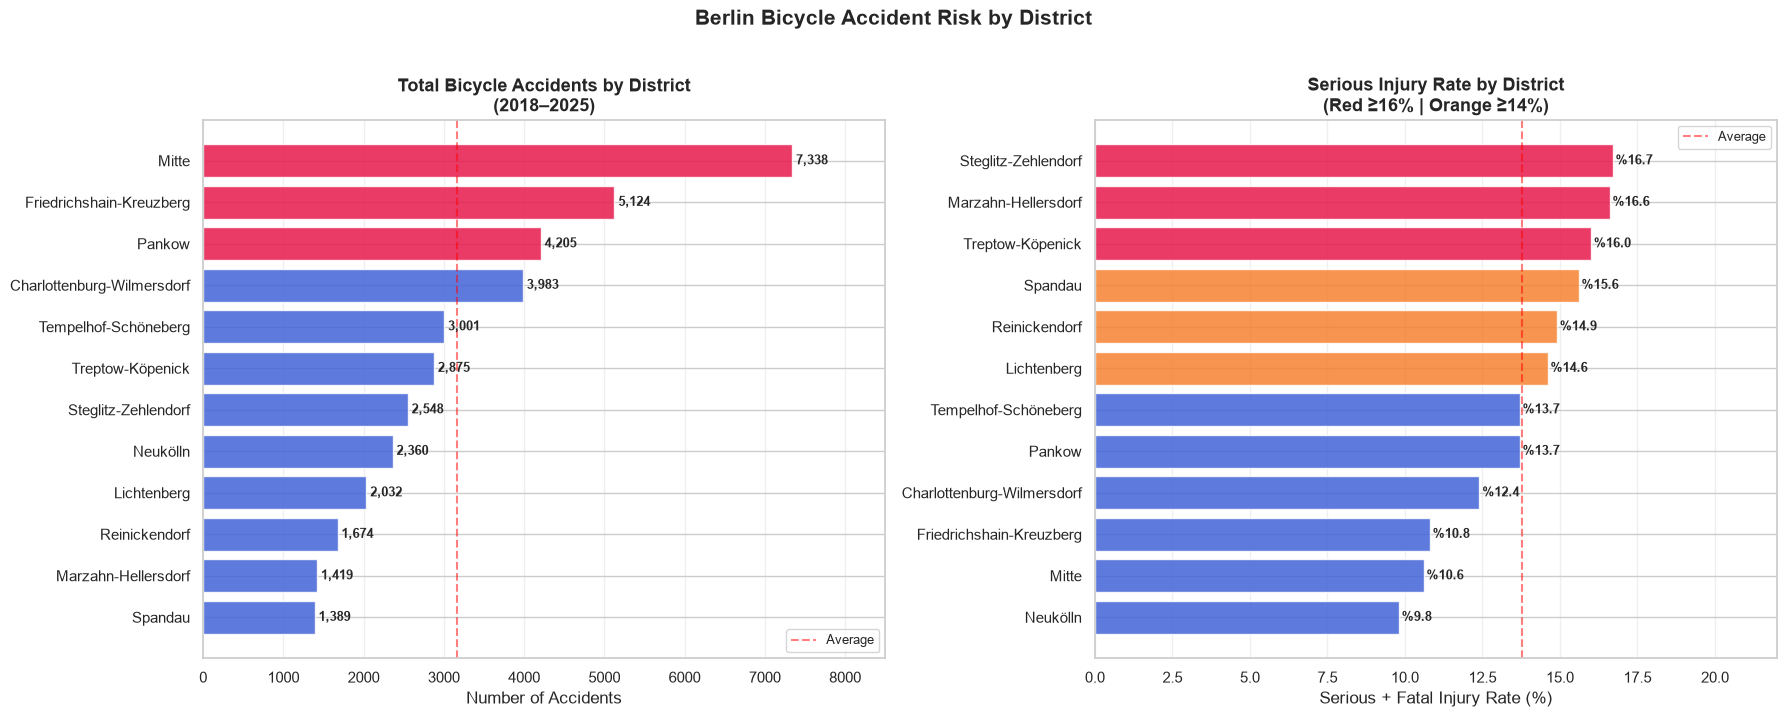

In [28]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Left: Total Bicycle Accidents by District
district_sorted = district_stats.sort_values('total_accidents', ascending=True)
colors_total = ['#e6194b' if d in ['Mitte', 'Friedrichshain-Kreuzberg', 'Pankow'] 
                else '#4363d8' for d in district_sorted['district_name']]

axes[0].barh(district_sorted['district_name'], 
             district_sorted['total_accidents'], 
             color=colors_total, alpha=0.85)
for i, (val, name) in enumerate(zip(district_sorted['total_accidents'], 
                                     district_sorted['district_name'])):
    axes[0].text(val + 50, i, f'{val:,}', va='center', fontsize=9, fontweight='bold')
axes[0].set_title('Total Bicycle Accidents by District\n(2018–2025)', 
                   fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Accidents')
axes[0].set_xlim(0, 8500)
axes[0].grid(axis='x', alpha=0.3)
axes[0].axvline(x=district_stats['total_accidents'].mean(), 
                color='red', linestyle='--', alpha=0.5, label='Average')
axes[0].legend(fontsize=9)

# Right: Serious Injury Rate by District
district_severity = district_stats.sort_values('serious_rate', ascending=True)
colors_severity = ['#e6194b' if r >= 16.0 else '#f58231' if r >= 14.0 
                   else '#4363d8' for r in district_severity['serious_rate']]

axes[1].barh(district_severity['district_name'], 
             district_severity['serious_rate'], 
             color=colors_severity, alpha=0.85)
for i, val in enumerate(district_severity['serious_rate']):
    axes[1].text(val + 0.1, i, f'%{val}', va='center', fontsize=9, fontweight='bold')
axes[1].set_title('Serious Injury Rate by District\n(Red ≥16% | Orange ≥14%)', 
                   fontsize=13, fontweight='bold')
axes[1].set_xlabel('Serious + Fatal Injury Rate (%)')
axes[1].set_xlim(0, 22)
axes[1].grid(axis='x', alpha=0.3)
axes[1].axvline(x=district_stats['serious_rate'].mean(), 
                color='red', linestyle='--', alpha=0.5, label='Average')
axes[1].legend(fontsize=9)

plt.suptitle('Berlin Bicycle Accident Risk by District', 
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../images/berlin_district_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

---
## 7. Geospatial Heatmap <a id='7-heatmap'></a>

An interactive heatmap weighted by accident severity (Fatal ×3 / Serious ×2 / Minor ×1) reveals the spatial distribution of high-risk zones across Berlin.


In [29]:
import os

import folium
from folium.plugins import HeatMap

# Coordinates were already cleaned and validated in section 2 (comma-to-dot
# conversion, bounding-box check). No re-cleaning here: doing the same work in
# two places is how the two copies eventually disagree.
geo_data = df_berlin_rad_final[["latitude", "longitude", "is_ksi"]].dropna().copy()

# ── Grid aggregation ──
# Rounding to 3 decimals gives ~111 m in latitude but ~68 m in longitude at
# Berlin's latitude, so cells are rectangular and their boundaries are arbitrary
# — a single junction can split across two cells. Week 2 replaces this with a
# projected grid (EPSG:25833) and snapping to OSM junctions.
geo_data["lat_grid"] = geo_data["latitude"].round(3)
geo_data["lon_grid"] = geo_data["longitude"].round(3)

hotspots = (
    geo_data.groupby(["lat_grid", "lon_grid"])
    .agg(accident_count=("is_ksi", "size"), ksi=("is_ksi", "sum"))
    .reset_index()
    .sort_values("accident_count", ascending=False)
    .head(10)
    .reset_index(drop=True)
)
hotspots["ksi_rate"] = (hotspots["ksi"] / hotspots["accident_count"]).round(3)

print("Top 10 locations by accident COUNT:")
print("Count is not risk. These are the busiest locations, which is not the same")
print("as the most dangerous — no cycling exposure denominator is available yet.")
print(f"KSI rate is shown for context (city-wide baseline: "
      f"{df_berlin_rad_final['is_ksi'].mean():.2%}).\n")
print(hotspots.to_string(index=False))

# ── Map ──
BERLIN_CENTRE = [52.5200, 13.4050]
m = folium.Map(location=BERLIN_CENTRE, zoom_start=12, tiles="OpenStreetMap")

heat_data = geo_data[["latitude", "longitude"]].values.tolist()
HeatMap(heat_data, radius=9, blur=10, max_zoom=13, min_opacity=0.3).add_to(m)

for idx, row in hotspots.iterrows():
    color = "red" if idx < 3 else "orange"
    folium.Marker(
        location=[row["lat_grid"], row["lon_grid"]],
        popup=(f"<b>Rank #{idx + 1}</b><br>"
               f"Accidents: {int(row['accident_count'])}<br>"
               f"KSI: {int(row['ksi'])} ({row['ksi_rate']:.1%})"),
        tooltip=f"#{idx + 1} — {int(row['accident_count'])} accidents",
        icon=folium.Icon(color=color, icon="warning", prefix="fa"),
    ).add_to(m)

os.makedirs("../reports", exist_ok=True)
OUT_MAP = "../reports/berlin_bike_accidents_heatmap.html"
m.save(OUT_MAP)
print(f"\nMap written: {OUT_MAP}")

m

Top 10 locations by accident COUNT:
Count is not risk. These are the busiest locations, which is not the same
as the most dangerous — no cycling exposure denominator is available yet.
KSI rate is shown for context (city-wide baseline: 12.99%).

 lat_grid  lon_grid  accident_count  ksi  ksi_rate
   52.516    13.454             107   14     0.131
   52.525    13.420              57    5     0.088
   52.504    13.410              51    7     0.137
   52.503    13.447              50    7     0.140
   52.493    13.388              48    5     0.104
   52.501    13.442              43    5     0.116
   52.516    13.381              42    2     0.048
   52.539    13.424              41    1     0.024
   52.504    13.411              41    2     0.049
   52.517    13.441              40    6     0.150

Map written: ../reports/berlin_bike_accidents_heatmap.html


In [33]:
import os

OUT = "../data/processed/berlin_bike_2018_2025.csv"
os.makedirs(os.path.dirname(OUT), exist_ok=True)
df_berlin_rad_final.to_csv(OUT, index=False)

print(f"Written: {OUT}")
print(f"  {len(df_berlin_rad_final):,} rows x {df_berlin_rad_final.shape[1]} columns")
print(f"  {os.path.getsize(OUT) / 1_048_576:.1f} MB")


Written: ../data/processed/berlin_bike_2018_2025.csv
  37,948 rows x 28 columns
  7.2 MB


In [34]:
import pandas as pd
df = pd.read_csv("../data/processed/berlin_bike_2018_2025.csv")
print(f"{len(df):,} rows, {df.shape[1]} cols")
print(f"KSI {df['is_ksi'].mean():.4f} | truck {(df['is_truck']==1).sum()} | "
      f"solo {(df['collision_type']=='Bicycle Only').sum()}")

37,948 rows, 28 cols
KSI 0.1299 | truck 767 | solo 5192


---
## Next Steps

- [ ] **Feature engineering** — rush hour flag, season, weekend/weekday
- [ ] **ML model** — XGBoost classifier for accident severity prediction
- [ ] **Route risk engine** — OSMnx + NetworkX for safe route recommendation
- [ ] **Streamlit dashboard** — interactive app combining all analyses
- [ ] **Claude API integration** — natural language route explanations
